# Banc d'essai -- `PixelTraceSource.normalized_signal`

Prend UNE video recalee (meme arborescence que `compute_one_cycle_pixel_svd.py`)
et affiche, etape par etape, ce que fait -- et ce que devrait faire -- la
normalisation d'intensite des traces pixel
(`motion/pulsation/traces/pixel.py`).

Le point de depart est `PixelTraceSource.raw_signal()` : une matrice `(T, N)`
d'intensites, une colonne par pixel/super-pixel de la ROI, concatenee sur les
echelles de bloc `block_sizes`. Deux normalisations distinctes sont possibles
sur cette matrice, et le code actuel de `normalized_signal` melange les deux :

| axe | operation | ce que ca enleve |
|---|---|---|
| `axis=0` (temps, **par trace**) | centrage-reduction (z-score) | l'heterogeneite de brillance ENTRE pixels |
| `axis=1` (traces, **par frame**) | division par la moyenne spatiale | la derive de gain/illumination COMMUNE a tous les pixels |

Le docstring annonce la premiere (*"zero mean, unit variance"*), le corps de la
methode calcule la seconde (`np.nanmean(sig, axis=1)`). Ce notebook les separe
pour qu'on puisse decider laquelle on veut -- et surtout mesurer le risque de
la seconde : la ROI etant entierement DANS la choroide, la pulsation
choroidienne est largement en phase d'un pixel a l'autre, donc la moyenne
spatiale par frame **contient le signal cardiaque**. Diviser par elle le
soustrait.

## Plan

0. signal brut `raw_signal()` -- ROI, traces, ordres de grandeur
1. statistiques **par trace** (`axis=0`) : la carte de brillance moyenne
2. statistique **par frame** (`axis=1`) : le diviseur du code actuel, et son spectre
3. variante A -- normalisation par frame (ce que fait le code aujourd'hui)
4. variante B -- z-score par trace (ce que dit le docstring)
5. variante C -- les deux enchainees
6. recapitulatif spectral des 4 variantes
7. effet en aval : SVD + puissance dans la bande cardiaque
8. etat actuel de `normalized_signal()` (appel reel)

In [ ]:
from pathlib import Path
import csv
import re
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from ocularrigidity.motion.pulsation import (
    CardiacBand,
    PixelTraceConfig,
    PixelTraceSource,
)
from ocularrigidity.motion.pulsation.rate import lomb_scargle_power
from ocularrigidity.motion.projection._1d import project_into_separable_components
from ocularrigidity.motion.video_timeline_aligner import VideoTimelineAligner
from ocularrigidity.scripts.one_cycle.astronauts import _prepared_registrator
from ocularrigidity.scripts.registration.astronauts import load_ordered_oct_series

# --- La condition inspectee (memes chemins que compute_one_cycle_pixel_svd.py) ---
PATH_GENERAL = Path("E:/SANSORI")            # arborescence brute (horodatages, HR)
SEGVAR_ROOT = Path("E:/NASA_Rigidity/SegmentationVariations")
MASK_VARIANT = "model1_scale_1.0"
# --- Choix de la condition ---------------------------------------------------
# Arborescence reelle :
#   E:/SANSORI/<NN>_<sujet>/<sujet>{before|post}_rigidity/
#                           <sujet>{before|post}_rigidity_<OD|OS>[replicat]
# Deux pieges que la resolution ci-dessous absorbe : le dossier "apres" est
# nomme "post" et non "after", et le suffixe de replicat est parfois ABSENT
# (un seul enregistrement pour cet oeil, ex. `..._OD`) parfois numerote
# (`..._OD1` a `..._OD5`). REPLICAT numerote donc les enregistrements
# DISPONIBLES, tries, a partir de 1 -- il ne suppose aucun suffixe.
ASTRO_NUM = 5            # 1 a 14
MOMENT_KEY = "before"    # "before" ou "after"
EYE = "OS"               # "OD" ou "OS"
REPLICAT = 1             # 1 = premier enregistrement disponible de cet oeil


def _replicat_num(path):
    """Suffixe numerique de replicat, 0 s'il n'y en a pas. Un tri numerique
    plutot que lexicographique : `_OD10` doit venir apres `_OD2`."""
    suffix = re.search(r"(\d*)$", path.name).group(1)
    return int(suffix) if suffix else 0


def resolve_condition(astro_num, moment_key, eye, replicat, root=PATH_GENERAL,
                      verbose=True):
    """(ASTRO, MOMENT, CONDITION) a partir d'un choix lisible.

    Leve une erreur listant ce qui existe reellement plutot que de renvoyer un
    chemin faux : les sujets n'ont ni les memes yeux ni le meme nombre de
    replicats.
    """
    astros = sorted(p for p in root.iterdir()
                    if p.is_dir() and re.fullmatch(r"\d{2}_\w+", p.name))
    match = [p for p in astros if int(p.name.split("_")[0]) == astro_num]
    if not match:
        dispo = ", ".join(p.name.split("_")[0] for p in astros)
        raise ValueError(f"astronaute {astro_num} absent ; disponibles : {dispo}")
    astro = match[0]
    subject = astro.name.split("_", 1)[1]

    key = {"before": "before", "after": "post", "post": "post"}.get(
        str(moment_key).lower())
    if key is None:
        raise ValueError(f"moment '{moment_key}' inconnu : 'before' ou 'after'")
    moment_dir = astro / f"{subject}{key}_rigidity"
    if not moment_dir.is_dir():
        dispo = ", ".join(p.name for p in sorted(astro.iterdir()) if p.is_dir())
        raise ValueError(f"{moment_dir.name} absent ; disponibles : {dispo}")

    conds = sorted((p for p in moment_dir.iterdir()
                    if p.is_dir() and re.search(rf"_{eye}\d*$", p.name)),
                   key=_replicat_num)
    if not conds:
        dispo = ", ".join(sorted(p.name.rsplit("_", 1)[-1]
                                 for p in moment_dir.iterdir() if p.is_dir()))
        raise ValueError(f"oeil {eye} absent de {moment_dir.name} ; "
                         f"disponibles : {dispo}")
    if not 1 <= replicat <= len(conds):
        noms = ", ".join(p.name.rsplit("_", 1)[-1] for p in conds)
        raise ValueError(f"replicat {replicat} hors bornes : "
                         f"{len(conds)} enregistrement(s) {eye} ({noms})")

    if verbose:
        noms = ", ".join(p.name.rsplit("_", 1)[-1] for p in conds)
        autres = ", ".join(sorted(p.name.rsplit("_", 1)[-1]
                                  for p in moment_dir.iterdir() if p.is_dir()))
        print(f"astronaute {astro_num:02d} ({subject}), {moment_key}, "
              f"replicat {replicat}/{len(conds)} de l'oeil {eye} [{noms}]")
        print(f"  enregistrements de ce moment : {autres}")
    return astro.name, moment_dir.name, conds[replicat - 1].name


ASTRO, MOMENT, CONDITION = resolve_condition(ASTRO_NUM, MOMENT_KEY, EYE, REPLICAT)

# --- PixelTraceConfig teste (defauts du package, explicites ici) ---
# ROW_FRAC couvre TOUTE l'epaisseur : c'est le decoupage regional (etape 9) qui
# la redivise en N_LAYERS tiers. La restreindre ici reviendrait a n'analyser
# qu'une partie de la choroide et les "couches" ne couvriraient plus l'epaisseur.
COL_FRAC = (0, 1)
ROW_FRAC = (0.0, 1.0)
BLOCK_SIZES = (1, 2, 3, 4, 5)

# --- Decoupage regional (etape 9) ---
# Couches : tiers de l'epaisseur LOCALE de la choroide, recalculee A-scan par
# A-scan. Colonnes : parts egales de l'etendue d'A-scans gardee par COL_FRAC.
N_LAYERS = 3
N_COLS_REG = 9
N_REGIONS = N_LAYERS * N_COLS_REG

# --- Bande cardiaque : large pour le DIAGNOSTIC (on veut voir les harmoniques
# et la derive basse frequence), etroite (BAND_FRAC autour de la HR mesuree)
# pour le SCORE, comme dans le script. ---
DIAG_BPM_RANGE = (20.0, 240.0)
BAND_FRAC = 0.2

# --- Sous-echantillonnage : N vaut 10^4-10^5 colonnes, on n'en trace qu'une
# poignee et on ne calcule les periodogrammes que sur un echantillon. ---
N_TRACES_PLOT = 6
N_TRACES_SPEC = 400
RNG = np.random.default_rng(0)

N_SVD_COMPONENTS = 100
# Par region il y a ~N_REGIONS fois moins de traces : on garde un rang plus
# faible, et il faut de toute facon que les spectres empiles restent lisibles.
N_SVD_REGION = 40

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", DEVICE)

astronaute 05 (210830001), before, replicat 1/1 de l'oeil OS [OS]
  enregistrements de ce moment : OD, OS
device = cuda


In [53]:
# Helpers de chemins/horodatages -- identiques a compute_one_cycle_pixel_svd.py.
# (SegmentationVariations n'ecrit pas de timestamp.txt : les horodatages sont
# recalcules depuis l'export XML Spectralis.)


def find_raw_dir(condition_dir: Path):
    for name in ("RawImages", "RawData"):
        d = condition_dir / name
        if d.is_dir():
            return d
    return None


def raw_timestamps_us(raw_dir: Path) -> np.ndarray:
    series = load_ordered_oct_series(raw_dir)
    return np.array(
        [int(round(s.acquisition_time.seconds_of_day * 1e6)) for s in series],
        dtype=np.int64,
    )


def read_hr(path_condi: Path) -> float:
    path_heartbeat = path_condi / "Data Files" / "visit_data.csv"
    if not path_heartbeat.exists():
        return float("nan")
    df = pd.read_csv(path_heartbeat, quoting=csv.QUOTE_NONE)
    return float(np.nanmean(pd.to_numeric(df["HR"], errors="coerce")))

In [54]:
condi_dir = PATH_GENERAL / ASTRO / MOMENT / CONDITION
variant_root = SEGVAR_ROOT / MASK_VARIANT
frames_path = variant_root / "registered_frames" / ASTRO / MOMENT / CONDITION / "cube.mp4"
mask_path = variant_root / "registered_masks" / ASTRO / MOMENT / CONDITION / "mask.npz"

for p in (condi_dir, frames_path, mask_path):
    if not p.exists():
        raise FileNotFoundError(p)

registrator = _prepared_registrator(frames_path, mask_path, DEVICE, verbose=False)
raw_dir = find_raw_dir(condi_dir)
if raw_dir is None:
    raise FileNotFoundError(f"RawImages/RawData absent : {condi_dir}")
ts_us = raw_timestamps_us(raw_dir)

n_frames = registrator.registered_frames.shape[0]
if n_frames != ts_us.size:
    raise ValueError(f"frames ({n_frames}) != horodatages ({ts_us.size})")

aligner = VideoTimelineAligner(registrator, ts_us)
t = aligner.timestamps_seconds          # (T,) horodatages reels, NON uniformes
hr = read_hr(condi_dir)
band = CardiacBand(
    expected_bpm=float(hr) if np.isfinite(hr) else None,
    expected_bpm_band_frac=BAND_FRAC,
)

print(f"{ASTRO} / {MOMENT} / {CONDITION}  (variante = {MASK_VARIANT})")
print(f"video     : {registrator.registered_frames.shape} {registrator.registered_frames.dtype}")
print(f"duree     : {t[-1] - t[0]:.2f} s, fs mediane = {aligner.fs:.2f} Hz")
print(f"HR mesuree: {hr:.1f} BPM" if np.isfinite(hr) else "HR mesuree: <absente>")

05_210830001 / 210830001before_rigidity / 210830001before_rigidity_OS  (variante = model1_scale_1.0)
video     : (401, 496, 768) uint8
duree     : 23.17 s, fs mediane = 18.87 Hz
HR mesuree: 61.0 BPM


## 0. Signal brut : `raw_signal()`

`raw_signal()` renvoie `(T, N)` : une colonne par pixel de la ROI (intersection
du masque dans le temps, restreinte par `col_frac`/`row_frac`) a l'echelle
`block=1`, PLUS une colonne par super-pixel median a chaque echelle superieure.
Aucun NaN ici (par construction, la ROI est valide sur toutes les frames), donc
`nanmean` et `mean` sont equivalents -- on garde `nanmean` pour coller au code
de `normalized_signal`.

In [55]:
source = PixelTraceSource(
    registrator,
    aligner,
    PixelTraceConfig(
        band=band,
        col_frac=COL_FRAC,
        row_frac=ROW_FRAC,
        block_sizes=BLOCK_SIZES,
        verbose=True,
    ),
)

sig0 = source.raw_signal().astype(np.float32)   # (T, N)
sig0n = source.normalized_signal().astype(np.float32)   # (T, N)
scale = source.scale_of_trace                    # (N,) echelle de bloc par colonne
roi = source.base_roi                            # (H, W) bool, echelle 1
is1 = scale == 1

print(f"raw_signal : {sig0.shape} {sig0.dtype}  ({sig0.nbytes / 1e6:.0f} Mo)")
for b in BLOCK_SIZES:
    print(f"  block {b}x{b} : {int((scale == b).sum()):>7d} traces")
print(f"ROI (block 1) : {int(roi.sum())} pixels sur {roi.size} "
      f"({roi.sum() / roi.size:.1%} de la frame)")
print(f"intensite     : min={sig0.min():.1f}  med={np.median(sig0):.1f}  max={sig0.max():.1f}")
print(f"NaN           : {int(np.isnan(sig0).sum())}")

raw_signal : (401, 69867) float32  (112 Mo)
  block 1x1 :   48313 traces
  block 2x2 :   11818 traces
  block 3x3 :    5131 traces
  block 4x4 :    2834 traces
  block 5x5 :    1771 traces
ROI (block 1) : 48313 pixels sur 380928 (12.7% de la frame)
intensite     : min=0.0  med=1.5  max=7.9
NaN           : 0


In [56]:
# --- Helpers de visualisation, partages par toutes les etapes ---

_rows = np.where(roi.any(axis=1))[0]
_cols = np.where(roi.any(axis=0))[0]
_BOX = (slice(_rows.min(), _rows.max() + 1), slice(_cols.min(), _cols.max() + 1))


def as_image(values_block1):
    """Remet un vecteur (N_block1,) a sa place dans le plan (H, W), recadre
    sur la boite englobante de la ROI. Hors ROI -> NaN."""
    img = np.full(roi.shape, np.nan, dtype=float)
    img[roi] = np.asarray(values_block1, dtype=float)
    return img[_BOX]


# Grille de frequences de DIAGNOSTIC (large), meme sur-echantillonnage x5 que
# LombScargleRateEstimator.score.
_df = 1.0 / (5.0 * (t[-1] - t[0]))
freqs = np.arange(DIAG_BPM_RANGE[0] / 60.0, DIAG_BPM_RANGE[1] / 60.0 + _df, _df)
bpm_axis = freqs * 60.0
# Bande de SCORE : celle que OptimizedSpectralCombination cherchera a maximiser.
if np.isfinite(hr):
    in_band = np.abs(bpm_axis - hr) <= BAND_FRAC * hr
else:
    in_band = (bpm_axis >= 30.0) & (bpm_axis <= 180.0)


def spectrum(y):
    """Lomb-Scargle d'une trace unique (centree), sur les horodatages reels.
    Les echantillons non finis sont ecartes plutot que propages."""
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(y)
    if ok.sum() < 8:
        return np.zeros_like(freqs)
    return lomb_scargle_power(t[ok], y[ok] - y[ok].mean(), freqs)


def mean_spectrum(sig, idx):
    """Puissance Lomb-Scargle moyenne sur un sous-echantillon de traces."""
    acc = np.zeros_like(freqs)
    for j in idx:
        acc += spectrum(sig[:, j])
    return acc / len(idx)


def mark_hr(ax):
    if np.isfinite(hr):
        ax.axvline(hr, color="C1", lw=1.6, ls="--", label=f"HR = {hr:.0f} BPM")
        ax.axvspan(bpm_axis[in_band].min(), bpm_axis[in_band].max(),
                   color="C1", alpha=0.12, lw=0)


def plot_traces(ax, sig, idx, title, demean=True):
    """Traces empilees. `demean` retire la moyenne temporelle de chaque trace
    (POUR L'AFFICHAGE seulement) : sans ca les offsets de brillance ecrasent
    completement les fluctuations."""
    vals = sig[:, idx].astype(float)
    if demean:
        vals = vals - np.nanmean(vals, axis=0, keepdims=True)
    step = 3.0 * np.nanmedian(np.nanstd(vals, axis=0)) + 1e-9
    for k in range(vals.shape[1]):
        ax.plot(t, vals[:, k] + k * step, lw=0.9)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("temps (s)")
    ax.set_yticks([])


# Les MEMES traces sont suivies dans toutes les etapes -> comparaisons valides.
_pool = np.where(is1)[0]
idx_plot = np.sort(RNG.choice(_pool, size=min(N_TRACES_PLOT, _pool.size), replace=False))
idx_spec = np.sort(RNG.choice(_pool, size=min(N_TRACES_SPEC, _pool.size), replace=False))
print(f"traces suivies : {idx_plot.tolist()}")
print(f"traces pour les spectres : {idx_spec.size}")

traces suivies : [1979, 13033, 14871, 24693, 30770, 41091]
traces pour les spectres : 400


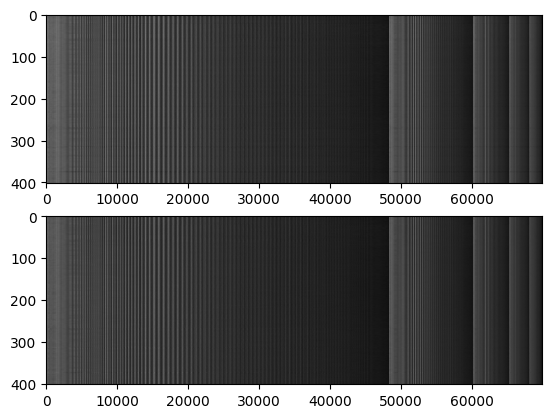

In [57]:
t_idx = [1,3,5,7,9]

sig1 = registrator.registered_frames[:,roi]
sigA = sig0 / np.mean(sig0,axis=1,keepdims=True)

#plt.figure(figsize=(4,4))
fig, axes = plt.subplots(nrows=2, ncols=1)#, gridspec_kw={"height_ratios": [1]})
#axes[0].imshow(registrator.registered_frames[t_idx[0]],cmap='gray')
#axes[1].imshow(registrator.registered_frames[t_idx[1]],cmap='gray')

axes[0].imshow(sig0,cmap='gray',aspect='auto')
axes[1].imshow(sig0n,cmap='gray',aspect='auto')

epaisseur de la choroide : 42 -> 85 px (mediane 63)
A-scans gardes : 741  (370 par colonne de region)
traces par region (toutes echelles / block 1) :
  #0   couche 0  colonne 0  :  18695 /  12927
  #1   couche 0  colonne 1  :  16494 /  11440
  #2   couche 1  colonne 0  :  18395 /  12710
  #3   couche 1  colonne 1  :  16283 /  11236


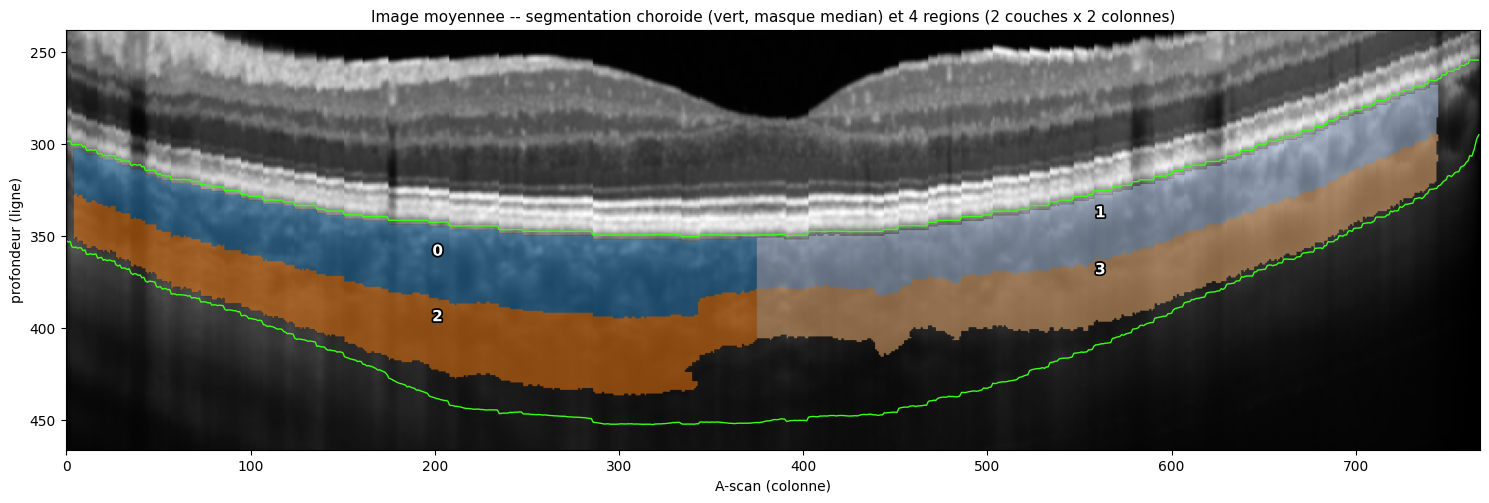

In [58]:
# --- Decoupage de la choroide en N_LAYERS x N_COLS_REG regions ---------------
# Numerotation : region = couche * N_COLS_REG + colonne, donc #0-4 = couche
# superieure (gauche -> droite), #5-9 = mediane, #10-14 = inferieure. C'est
# aussi l'ordre des sous-graphes dans toutes les figures qui suivent.
roi = source.base_roi

# `as_image` lit `roi` et `_BOX` a l'appel : on rafraichit la boite englobante
# ici, au cas ou COL_FRAC/ROW_FRAC aient change depuis la cellule des helpers.
_rows = np.where(roi.any(axis=1))[0]
_cols = np.where(roi.any(axis=0))[0]
_BOX = (slice(_rows.min(), _rows.max() + 1), slice(_cols.min(), _cols.max() + 1))

# Colonnes : parts egales de l'etendue d'A-scans effectivement gardee.
col_group_of_x = np.full(roi.shape[1], -1, dtype=int)
_rank = np.arange(_cols.size) / _cols.size
col_group_of_x[_cols] = np.minimum((_rank * N_COLS_REG).astype(int), N_COLS_REG - 1)

# Couches : tiers de l'epaisseur LOCALE. La choroide n'a ni la meme epaisseur
# ni la meme profondeur d'un A-scan a l'autre -- un decoupage en lignes fixes
# melangerait les couches d'une colonne a l'autre.
region_of_pixel = np.full(roi.shape, -1, dtype=int)
thickness_px = np.zeros(_cols.size)
for j, x in enumerate(_cols):
    rows = np.where(roi[:, x])[0]
    span = rows[-1] - rows[0] + 1
    thickness_px[j] = span
    layer = np.minimum(((rows - rows[0]) / span * N_LAYERS).astype(int), N_LAYERS - 1)
    region_of_pixel[rows, x] = layer * N_COLS_REG + col_group_of_x[x]

# Region de CHAQUE colonne de sig0/sig0n, toutes echelles de bloc confondues.
# `raw_signal` concatene les echelles dans l'ordre de BLOCK_SIZES, chaque bloc
# etant garde seulement s'il est entierement dans la ROI -> son pixel central
# est donc toujours dans la ROI, et sa region est bien definie.
_region_of_trace = []
for b in BLOCK_SIZES:
    roi_b = PixelTraceSource._block_all(roi, b)
    if int(roi_b.sum()) == 0:
        continue                                  # meme saut que raw_signal()
    if b == 1:
        reg_b = region_of_pixel
    else:
        h, w = roi.shape
        hc, wc = h - h % b, w - w % b
        reg_b = region_of_pixel[b // 2:hc:b, b // 2:wc:b]   # pixel central
    _region_of_trace.append(reg_b[roi_b])
region_of_trace = np.concatenate(_region_of_trace)
assert region_of_trace.size == sig0.shape[1], "desalignement traces <-> regions"
assert (region_of_trace >= 0).all(), "des traces hors region"

# Position image de chaque trace block-1 (-1 pour les autres echelles) : sert a
# reprojeter les motifs spatiaux V dans le plan de l'image.
pix_rc = np.argwhere(roi)                          # ordre C = ordre des colonnes
pix_index_of_trace = np.full(region_of_trace.size, -1, dtype=int)
pix_index_of_trace[np.where(is1)[0]] = np.arange(pix_rc.shape[0])

print(f"epaisseur de la choroide : {thickness_px.min():.0f} -> {thickness_px.max():.0f} px "
      f"(mediane {np.median(thickness_px):.0f})")
print(f"A-scans gardes : {_cols.size}  ({_cols.size / N_COLS_REG:.0f} par colonne de region)")
print("traces par region (toutes echelles / block 1) :")
for r in range(N_REGIONS):
    m = region_of_trace == r
    print(f"  #{r:<3d} couche {r // N_COLS_REG}  colonne {r % N_COLS_REG}  :"
          f" {int(m.sum()):>6d} / {int((m & is1).sum()):>6d}")

# --- Figure : image moyennee + segmentation + les 15 regions numerotees -------
mean_frame = registrator.registered_frames.mean(axis=0)
mask_prob = registrator.registered_masks.astype(bool).mean(axis=0)
CMAP_REG = plt.get_cmap("tab20")

fig, ax = plt.subplots(figsize=(15, 5.0))
ax.imshow(mean_frame, cmap="gray")
cs = ax.contour(mask_prob, levels=[0.5], colors="#39ff14", linewidths=1.0)
overlay = np.zeros((*roi.shape, 4))
for r in range(N_REGIONS):
    overlay[region_of_pixel == r] = (*CMAP_REG(r % 20)[:3], 0.50)
ax.imshow(overlay)
for r in range(N_REGIONS):
    rc = np.argwhere(region_of_pixel == r)
    if rc.size == 0:
        continue
    ax.text(rc[:, 1].mean(), rc[:, 0].mean(), str(r),
            color="white", fontsize=11, fontweight="bold", ha="center", va="center",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="black")])
MARGIN = 30
ax.set_ylim(min(_rows.max() + MARGIN, roi.shape[0] - 1), max(_rows.min() - MARGIN, 0))
ax.set_title(f"Image moyennee -- segmentation choroide (vert, masque median) et "
             f"{N_REGIONS} regions ({N_LAYERS} couches x {N_COLS_REG} colonnes)",
             fontsize=11)
ax.set_xlabel("A-scan (colonne)")
ax.set_ylabel("profondeur (ligne)")
fig.tight_layout()


#0   pic =   30.9 BPM   en bande = 19.44%
#1   pic =   31.4 BPM   en bande = 13.49%
#2   pic =   42.8 BPM   en bande = 14.42%
#3   pic =   30.4 BPM   en bande = 23.56%


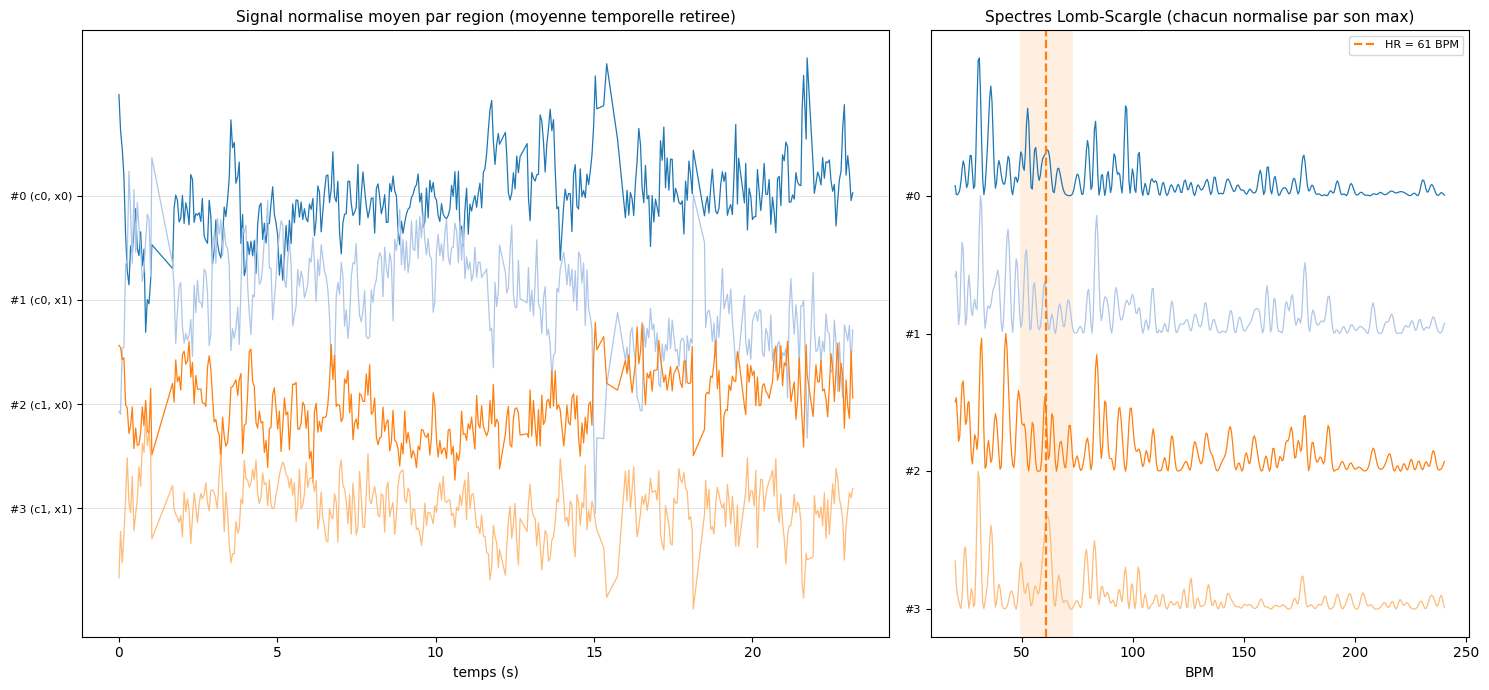

In [59]:
# --- Signal normalise de chaque region ---------------------------------------
# Une trace par region = moyenne de ses colonnes de `sig0n` (toutes echelles de
# bloc). Sert de reference de signe plus bas : la combinaison optimisee d'une
# region sera retournee pour correler positivement avec elle.
sig_reg = np.stack(
    [np.nanmean(sig0n[:, region_of_trace == r], axis=1) for r in range(N_REGIONS)],
    axis=1,
)                                                     # (T, N_REGIONS)
P_reg = np.stack([spectrum(sig_reg[:, r]) for r in range(N_REGIONS)], axis=1)
peak_reg = bpm_axis[P_reg.argmax(axis=0)]
frac_reg = P_reg[in_band].sum(axis=0) / (P_reg.sum(axis=0) + 1e-12)

for r in range(N_REGIONS):
    flag = "  <-- pic en bande" if in_band[P_reg[:, r].argmax()] else ""
    print(f"#{r:<3d} pic = {peak_reg[r]:6.1f} BPM   en bande = {frac_reg[r]:6.2%}{flag}")

fig, axes = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"width_ratios": [1.5, 1]})

vals = sig_reg - sig_reg.mean(axis=0, keepdims=True)
step = 3.0 * float(np.median(vals.std(axis=0))) + 1e-12
for r in range(N_REGIONS):
    off = (N_REGIONS - 1 - r) * step                  # #0 en haut, comme l'image
    axes[0].plot(t, vals[:, r] + off, lw=0.9, color=CMAP_REG(r % 20))
    axes[0].axhline(off, color="0.85", lw=0.5, zorder=0)
axes[0].set_yticks([(N_REGIONS - 1 - r) * step for r in range(N_REGIONS)])
axes[0].set_yticklabels([f"#{r} (c{r // N_COLS_REG}, x{r % N_COLS_REG})"
                         for r in range(N_REGIONS)], fontsize=8)
axes[0].set_title("Signal normalise moyen par region (moyenne temporelle retiree)",
                  fontsize=11)
axes[0].set_xlabel("temps (s)")

for r in range(N_REGIONS):
    off = (N_REGIONS - 1 - r) * 1.0
    Pr = P_reg[:, r]
    axes[1].plot(bpm_axis, Pr / (Pr.max() + 1e-12) + off, lw=0.9,
                 color=CMAP_REG(r % 20))
mark_hr(axes[1])
axes[1].set_yticks(np.arange(N_REGIONS))
axes[1].set_yticklabels([f"#{N_REGIONS - 1 - k}" for k in range(N_REGIONS)], fontsize=8)
axes[1].set_title("Spectres Lomb-Scargle (chacun normalise par son max)", fontsize=11)
axes[1].set_xlabel("BPM")
axes[1].legend(fontsize=8)
fig.tight_layout()


#0    18695 traces  ->  40 composantes, 15 piquent en bande
#1    16494 traces  ->  40 composantes, 19 piquent en bande
#2    18395 traces  ->  40 composantes, 13 piquent en bande
#3    16283 traces  ->  40 composantes, 10 piquent en bande


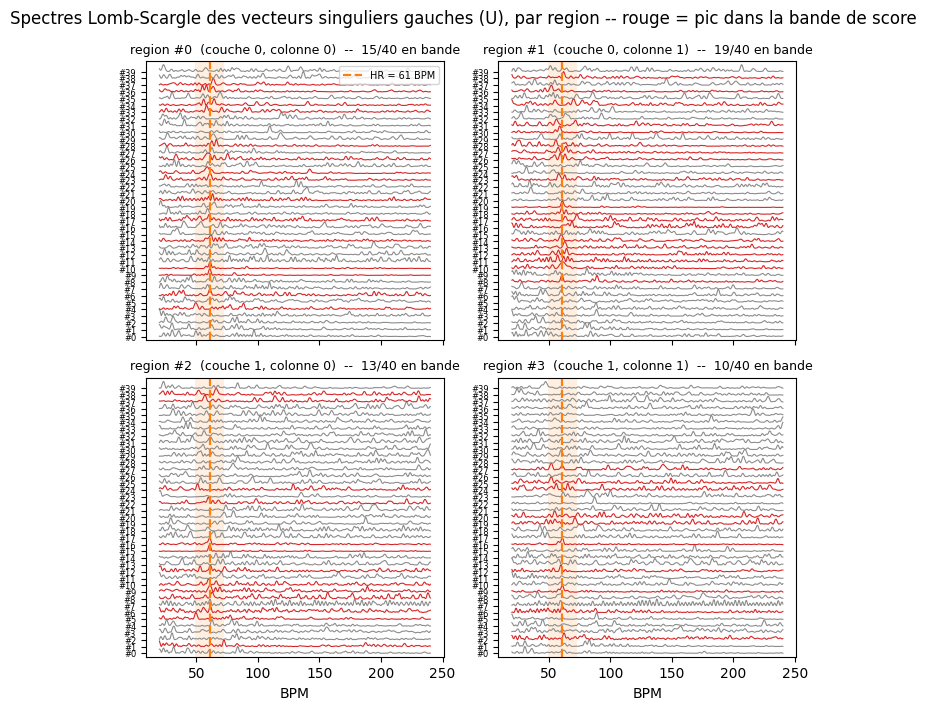

In [60]:
# --- SVD, une par region -----------------------------------------------------
svd_reg = {}
for r in range(N_REGIONS):
    cols_r = np.where(region_of_trace == r)[0]
    Xr = np.nan_to_num(sig0n[:, cols_r], nan=0.0)
    k = int(min(N_SVD_REGION, Xr.shape[0], Xr.shape[1]))
    Ur, Vr = project_into_separable_components(
        Xr,
        method="svd",
        n_components=k,
        normalize=False,      # True = centre chaque colonne avant la SVD
        random_state=0,
    )
    # Ur : (T, k) = U * S, composantes temporelles
    # Vr : (N_r, k) = V, motif spatial de chaque composante
    Pr = np.stack([spectrum(Ur[:, i]) for i in range(k)], axis=1)   # (F, k)
    jmax = Pr.argmax(axis=0)
    svd_reg[r] = {
        "cols": cols_r,
        "U": Ur,
        "V": Vr,
        "P": Pr,
        "peak_bpm": bpm_axis[jmax],
        "in_band": in_band[jmax],
        "frac": Pr[in_band].sum(axis=0) / (Pr.sum(axis=0) + 1e-12),
    }
    print(f"#{r:<3d} {cols_r.size:>6d} traces  ->  {k} composantes, "
          f"{int(svd_reg[r]['in_band'].sum())} piquent en bande")

# --- Figure : spectres empiles, un sous-graphe par region --------------------
# La grille reproduit la disposition des regions dans l'image : ligne = couche
# (0 = superieure), colonne = position en x.
fig, axes = plt.subplots(N_LAYERS, N_COLS_REG,
                         figsize=(3.6 * N_COLS_REG, 3.6 * N_LAYERS),
                         sharex=True)
for r in range(N_REGIONS):
    ax = axes[r // N_COLS_REG][r % N_COLS_REG]
    d = svd_reg[r]
    K = d["P"].shape[1]
    for k in range(K):                                 # #0 en bas
        Pk = d["P"][:, k]
        ax.plot(bpm_axis, Pk / (Pk.max() + 1e-12) + k, lw=0.8,
                color="C3" if d["in_band"][k] else "0.55")
    mark_hr(ax)
    ax.set_title(f"region #{r}  (couche {r // N_COLS_REG}, colonne {r % N_COLS_REG})"
                 f"  --  {int(d['in_band'].sum())}/{K} en bande", fontsize=9)
    ax.set_yticks(np.arange(K))
    ax.set_yticklabels([f"#{k}" for k in range(K)], fontsize=6)
    ax.set_ylim(-0.5, K + 0.5)
    if r // N_COLS_REG == N_LAYERS - 1:
        ax.set_xlabel("BPM")
axes[0][0].legend(fontsize=7, loc="upper right")
fig.suptitle("Spectres Lomb-Scargle des vecteurs singuliers gauches (U), par region "
             "-- rouge = pic dans la bande de score", fontsize=12)
fig.tight_layout()


fenetres d'optimisation : 3 x 8 cycles (~7.9 s) sur 23.2 s de video
passe-bande : 48.8-73.2 BPM (0.813-1.220 Hz)  |  fs = 18.87 Hz, cutoffs normalises = 0.0862/0.1293

#0    9 candidates -> pic   60.9 BPM, en bande 62.47% (vs 32.09% pour la meilleure seule #9), objectif -0.4554,   0.9 s
#1    7 candidates -> pic   60.9 BPM, en bande 54.63% (vs 38.87% pour la meilleure seule #19), objectif -0.3061,   0.9 s
#2    2 candidates -> pic   60.9 BPM, en bande 43.44% (vs 33.02% pour la meilleure seule #15), objectif -0.1822,   0.2 s
#3    2 candidates -> pic   60.9 BPM, en bande 36.77% (vs 29.25% pour la meilleure seule #16), objectif -0.1667,   0.4 s


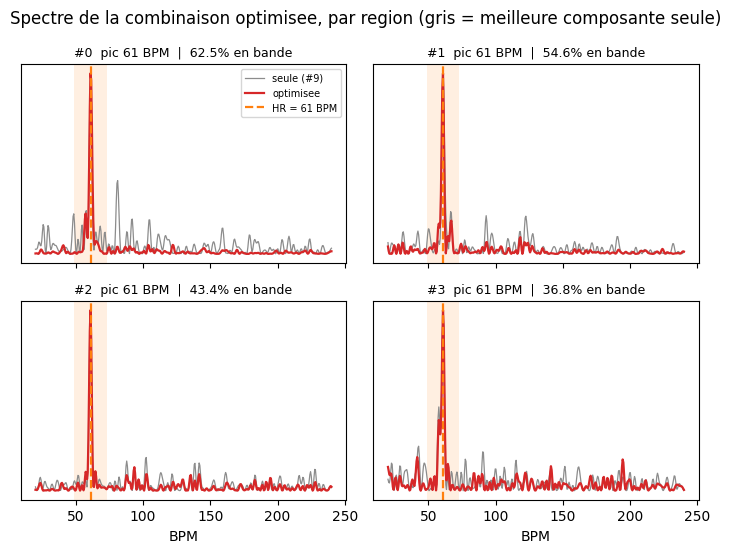

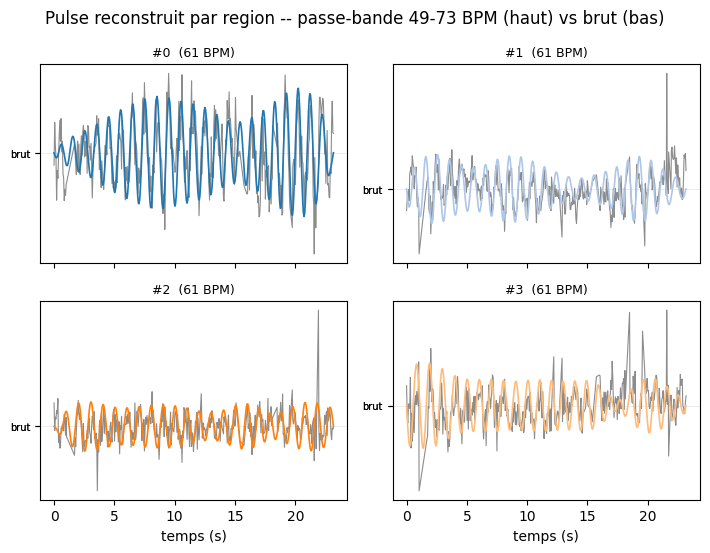

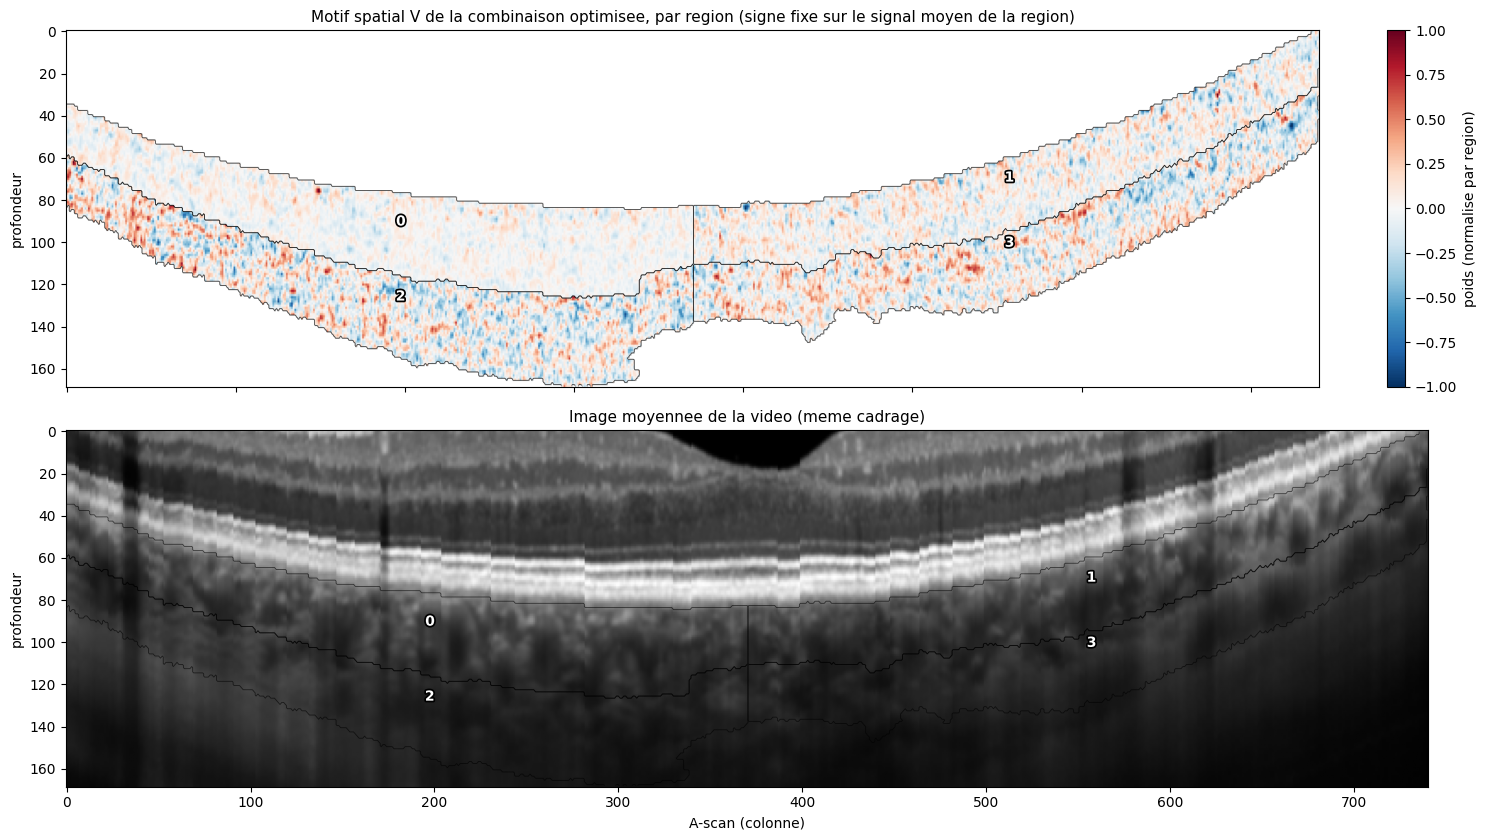

In [ ]:
# --- Optimisation de la combinaison, une par region --------------------------
from ocularrigidity.motion.pulsation.traces import Traces
from ocularrigidity.motion.pulsation.rate import (
    LombScargleConfig,
    LombScargleRateEstimator,
)
from ocularrigidity.motion.pulsation.phase import (
    OptimizedSpectralCombination,
    SpectralCombinationConfig,
)
from ocularrigidity.motion.filters._1d import spatio_temporal_filter

# Bande LARGE pour le rate estimator : son `freqs` sert aussi de grille
# hors-bande dans l'objectif (e_out). Avec `band` (+/-BAND_FRAC de la HR) il n'y
# aurait presque aucun point hors bande et le rapport a maximiser serait
# degenere. `override_bpm` fixe la cible a la HR mesuree, sans re-estimation.
RATE_EST = LombScargleRateEstimator(
    LombScargleConfig(band=CardiacBand(bpm_range=DIAG_BPM_RANGE), verbose=False),
    override_bpm=float(hr),
)
# n_restarts/maxiter reduits : l'objectif recalcule un Lomb-Scargle complet a
# chaque evaluation ET PAR FENETRE, et on optimise 15 fois. Remonter pour un
# run "propre" (le cout est multiplie par N_WINDOWS).
#
# Fenetrage temporel : l'energie a maximiser est la SOMME des energies en bande
# obtenues sur N_WINDOWS fenetres de WINDOW_N_CYCLES cycles cardiaques,
# egalement reparties dans le temps (elles peuvent se recouvrir). Une
# combinaison qui n'est cardiaque que sur une partie de l'acquisition ne peut
# donc plus gagner sur son spectre integre. Une fenetre plus longue que la
# video + N_WINDOWS = 1 redonne exactement l'objectif global d'origine.
WINDOW_N_CYCLES = 6
N_WINDOWS = 5
OPT_CFG = SpectralCombinationConfig(
    accept_tol_bpm=BAND_FRAC * hr,     # meme bande que `in_band`
    min_concentration=0.15,
    max_candidates=12,
    n_restarts=4,
    maxiter=100,
    random_state=0,
    window_n_cycles=WINDOW_N_CYCLES,
    n_windows=N_WINDOWS,
)
print(f"fenetres d'optimisation : {N_WINDOWS} x {WINDOW_N_CYCLES:.0f} cycles "
      f"(~{WINDOW_N_CYCLES * 60.0 / hr:.1f} s) sur {t[-1] - t[0]:.1f} s de video")

# --- Passe-bande : exactement celui de la chaine de reconstruction -----------
# `AbstractUniformTraceSource.filtered_signal` (base.py:217) appelle
# `spatio_temporal_filter` avec des frequences de coupure normalisees par
# Nyquist et la bande physiologique `band`. Meme fonction, memes cutoffs, sans
# lissage spatial (on filtre une trace unique).
_NYQ = 0.5 * aligner.fs
_LO_BPM, _HI_BPM = band.effective_bpm_range
_LOW = (_LO_BPM / 60.0) / _NYQ
_HIGH = min((_HI_BPM / 60.0) / _NYQ, 0.99)
u_time = aligner.uniform_time


def bandpass_pulse(y):
    """Passe-bande cardiaque sur une trace unique.

    Le FIR suppose un echantillonnage uniforme ; `y` vit sur les horodatages
    reels `t`, qui ne le sont pas. On l'interpole donc d'abord sur la grille de
    l'aligner -- exactement ce que fait `filtered_signal`, qui filtre
    `interpolated_signal` et non le signal brut. Le resultat vit sur `u_time`.
    """
    yu = np.interp(u_time, t, y)
    return spatio_temporal_filter(
        yu[:, None],
        spatial_sigma=0.0,
        temporal_low_freq=_LOW,
        temporal_high_freq=_HIGH,
        fs=aligner.fs,
        validity_mask=None,
    )[:, 0]


print(f"passe-bande : {_LO_BPM:.1f}-{_HI_BPM:.1f} BPM "
      f"({_LO_BPM / 60:.3f}-{_HI_BPM / 60:.3f} Hz)  |  fs = {aligner.fs:.2f} Hz, "
      f"cutoffs normalises = {_LOW:.4f}/{_HIGH:.4f}\n")

opt_reg = {}
for r in range(N_REGIONS):
    d = svd_reg[r]
    traces_r = Traces(
        values=np.asarray(d["U"], dtype=np.float64),
        uniform_time=t,
        kept_mask=np.ones(t.size, dtype=bool),
        gap_mask=np.zeros(t.size, dtype=bool),
        timestamps_seconds=t,
        mixing=np.asarray(d["V"], dtype=np.float64),
    )
    rate_r = RATE_EST.estimate(traces_r)
    agg_r = OptimizedSpectralCombination(OPT_CFG)
    t0 = time.perf_counter()
    try:
        y = agg_r.aggregate(traces_r, rate_r)
    except ValueError as exc:
        opt_reg[r] = None
        print(f"#{r:<3d} ECHEC : {exc}")
        continue
    res_r = agg_r.last_result
    pattern = res_r.spatial_pattern

    # Le signe d'une SVD est arbitraire : on le fixe pour que la combinaison
    # correle positivement avec le signal moyen de la region. Sans ca les
    # motifs spatiaux de deux regions voisines ne sont pas comparables.
    c = np.corrcoef(y, sig_reg[:, r])[0, 1]
    if np.isfinite(c) and c < 0:
        y, pattern = -y, -pattern

    P_y = spectrum(y)
    k_best = int(res_r.selected_indices[np.argmax(d["frac"][res_r.selected_indices])])
    opt_reg[r] = {
        "y": y,                              # sur `t` (horodatages reels)
        "y_filt": bandpass_pulse(y),         # sur `u_time` (grille uniforme)
        "P": P_y,
        "pattern": pattern,
        "frac": float(P_y[in_band].sum() / (P_y.sum() + 1e-12)),
        "peak_bpm": float(bpm_axis[P_y.argmax()]),
        "selected": res_r.selected_indices,
        "weights": res_r.weights,
        "objective": res_r.objective,
        "windows": res_r.windows_seconds,          # (n_fenetres, 2), en s
        "window_objectives": res_r.window_objectives,
        "k_best": k_best,
    }
    print(f"#{r:<3d} {res_r.selected_indices.size:>2d} candidates -> pic "
          f"{opt_reg[r]['peak_bpm']:6.1f} BPM, en bande {opt_reg[r]['frac']:6.2%} "
          f"(vs {d['frac'][k_best]:6.2%} pour la meilleure seule #{k_best}), "
          f"objectif {res_r.objective:+.4f}, {time.perf_counter() - t0:5.1f} s")


def _grid(title):
    fig, axes = plt.subplots(N_LAYERS, N_COLS_REG,
                             figsize=(3.6 * N_COLS_REG, 2.8 * N_LAYERS), sharex=True)
    fig.suptitle(title, fontsize=12)
    return fig, axes


def _empty(ax, r):
    ax.text(0.5, 0.5, f"#{r}\naucune candidate", ha="center", va="center",
            transform=ax.transAxes, fontsize=9, color="C3")
    ax.set_xticks([])
    ax.set_yticks([])


# --- Spectres de la combinaison optimisee ------------------------------------
fig, axes = _grid("Spectre de la combinaison optimisee, par region "
                  "(gris = meilleure composante seule)")
for r in range(N_REGIONS):
    ax = axes[r // N_COLS_REG][r % N_COLS_REG]
    o = opt_reg[r]
    if o is None:
        _empty(ax, r)
        continue
    Pb = svd_reg[r]["P"][:, o["k_best"]]
    ax.plot(bpm_axis, Pb / (Pb.max() + 1e-12), lw=0.9, color="0.55",
            label=f"seule (#{o['k_best']})")
    ax.plot(bpm_axis, o["P"] / (o["P"].max() + 1e-12), lw=1.6, color="C3",
            label="optimisee")
    mark_hr(ax)
    ax.set_title(f"#{r}  pic {o['peak_bpm']:.0f} BPM  |  {o['frac']:.1%} en bande",
                 fontsize=9)
    ax.set_yticks([])
    if r // N_COLS_REG == N_LAYERS - 1:
        ax.set_xlabel("BPM")
axes[0][0].legend(fontsize=7)
fig.tight_layout()

# --- Pulse reconstruit : filtre (haut) vs brut (bas) -------------------------
# Les deux traces sont reduites (divisees par leur ecart-type) avant d'etre
# decalees : le passe-bande retire une partie de la variance, les tracer a la
# meme echelle absolue ecraserait le filtre. On compare des FORMES.
PULSE_OFFSET = 0.0
fig, axes = _grid(f"Pulse reconstruit par region -- passe-bande "
                  f"{_LO_BPM:.0f}-{_HI_BPM:.0f} BPM (haut) vs brut (bas)")
for r in range(N_REGIONS):
    ax = axes[r // N_COLS_REG][r % N_COLS_REG]
    o = opt_reg[r]
    if o is None:
        _empty(ax, r)
        continue
    yn = o["y"] / (np.nanstd(o["y"]) + 1e-9)
    yf = o["y_filt"] / (np.nanstd(o["y_filt"]) + 1e-9)
    ax.axhline(PULSE_OFFSET, color="0.9", lw=0.5, zorder=0)
    ax.plot(t, yn, lw=0.8, color="0.55")
    ax.plot(u_time, yf + PULSE_OFFSET, lw=1.2, color=CMAP_REG(r % 20))
    ax.set_title(f"#{r}  ({o['peak_bpm']:.0f} BPM)", fontsize=9)
    ax.set_yticks([PULSE_OFFSET, 0.0])
    ax.set_yticklabels(["filtre", "brut"], fontsize=7)
    if r // N_COLS_REG == N_LAYERS - 1:
        ax.set_xlabel("temps (s)")
fig.tight_layout()

# --- Carte des motifs spatiaux (V) vs image moyennee -------------------------
# Chaque region est normalisee par son propre max|.| : les valeurs singulieres
# ne sont pas comparables d'une region a l'autre, seule la STRUCTURE l'est.
Vmap = np.full(roi.shape, np.nan)
for r in range(N_REGIONS):
    o = opt_reg[r]
    if o is None:
        continue
    pi = pix_index_of_trace[svd_reg[r]["cols"]]
    ok = pi >= 0                                   # colonnes block-1 seulement
    p = np.asarray(o["pattern"], dtype=float)[ok]
    Vmap[pix_rc[pi[ok], 0], pix_rc[pi[ok], 1]] = p / (np.abs(p).max() + 1e-12)

fig, axes = plt.subplots(2, 1, figsize=(15, 8.5), sharex=True, sharey=True)
im = axes[0].imshow(Vmap[_BOX], cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
fig.colorbar(im, ax=axes[0], fraction=0.03, label="poids (normalise par region)")
axes[0].set_title("Motif spatial V de la combinaison optimisee, par region "
                  "(signe fixe sur le signal moyen de la region)", fontsize=11)
axes[0].set_ylabel("profondeur")

axes[1].imshow(mean_frame[_BOX], cmap="gray", aspect="auto")
axes[1].set_title("Image moyennee de la video (meme cadrage)", fontsize=11)
axes[1].set_xlabel("A-scan (colonne)")
axes[1].set_ylabel("profondeur")

reg_box = region_of_pixel[_BOX]
for ax in axes:
    for r in range(N_REGIONS):
        m = reg_box == r
        if not m.any():
            continue
        ax.contour(m.astype(float), levels=[0.5], colors="k", linewidths=0.6,
                   alpha=0.6)
        rc = np.argwhere(m)
        ax.text(rc[:, 1].mean(), rc[:, 0].mean(), str(r), color="white", fontsize=10,
                fontweight="bold", ha="center", va="center",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="black")])
fig.tight_layout()


pas de temps uniforme : 53.0 ms   |   fenetre de lag : +/-1.97 s (2 cycles)
paires : 4x4 = 16 (6 distinctes + 4 autocorrelations)
  bruts    : 0.00 s  |  correlation a lag 0 -0.47 -> +0.58 (mediane -0.09)  |  |lag| au pic : max 530 ms, mediane 397 ms
  filtres  : 0.00 s  |  correlation a lag 0 -0.85 -> +0.76 (mediane -0.61)  |  |lag| au pic : max 1961 ms, mediane 503 ms

figures en tuiles : 2 x (4 tuiles x 4 cases) = 32 panneaux, annotations activees (rendu potentiellement lent)

lag retenu (tous les pics de |xc|, choix lisse ancre sur lag 0) :
  pics par paire : mediane 7, max 8  |  selection : 0.0 s
  |lag| : max   78.5 ms, mediane   39.6 ms (pas de temps = 53.0 ms)
  correlation au pic retenu : mediane +0.731
  cases ou le pic retenu n'est PAS le plus proche de 0 : 0 / 12
  rugosite spatiale totale : 811 -> 811 ms (0% de moins)
  antisymetrie |lag[i,j] + lag[j,i]| : max 0.0 ms


Text(0.5, 0.98, "Lag de |correlation croisee| : parmi TOUS les pics, celui qui lisse le mieux la carte (pulses filtres)\ntuile = region de reference i (haut-gauche = #0), pixel = region j a sa place dans l'image ; croix = la reference, ancree a lag 0 ; point blanc = pic autre que le plus proche de 0 ; lag > 0 : j est EN RETARD sur i")

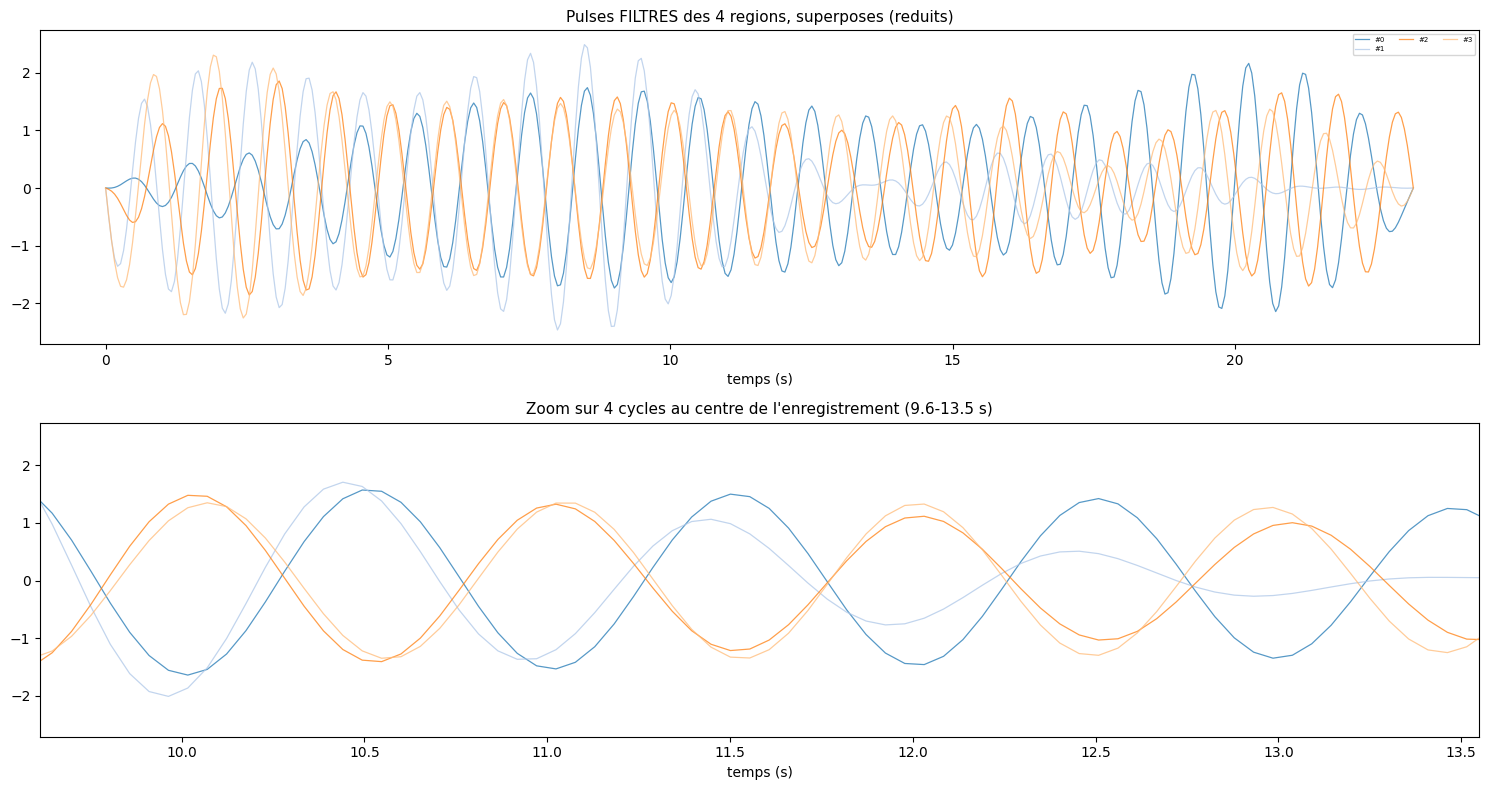

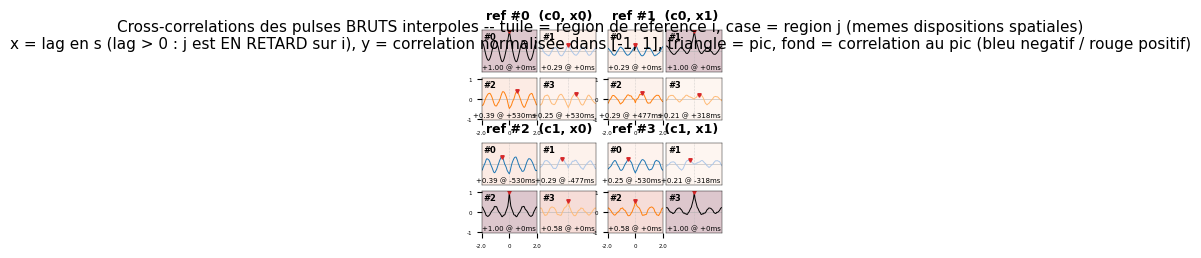

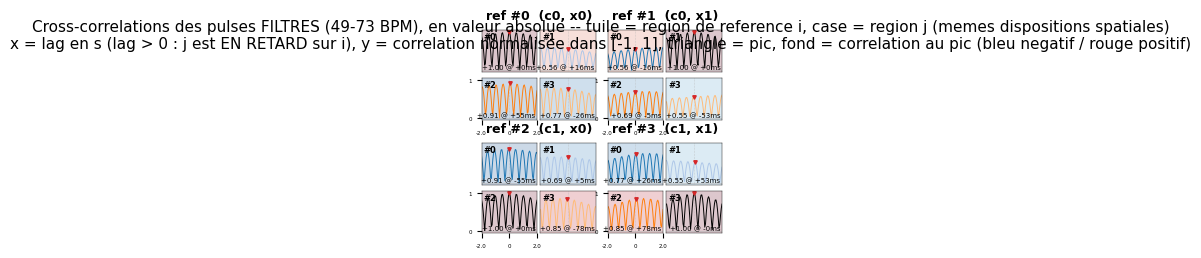

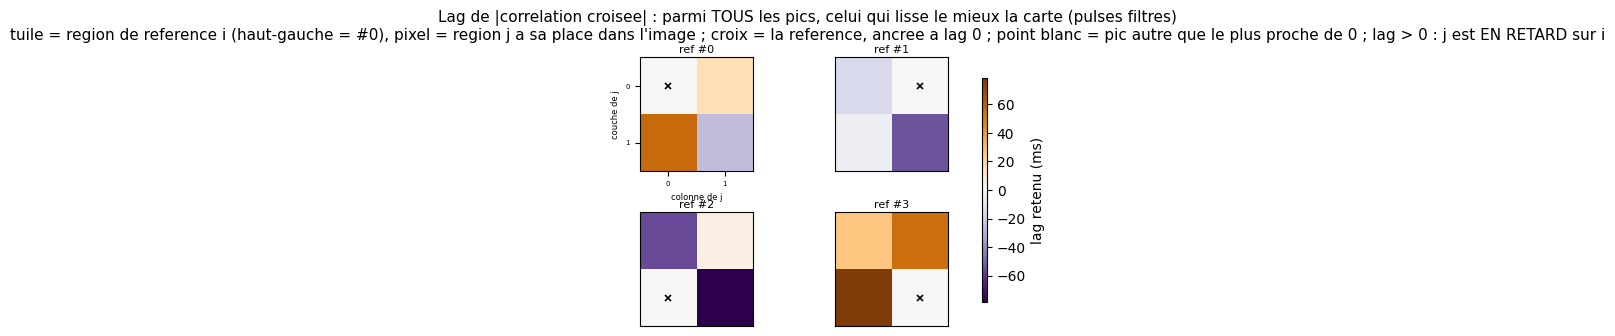

In [62]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

VALID = [r for r in range(N_REGIONS) if opt_reg[r] is not None]

# --- 1. Pulses FILTRES, superposes -------------------------------------------
# Reduits (divises par leur ecart-type) : les amplitudes ne sont pas comparables
# d'une region a l'autre (valeurs singulieres arbitraires), la PHASE l'est.
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
for r in VALID:
    yf = opt_reg[r]["y_filt"]
    yf = yf / (np.nanstd(yf) + 1e-9)
    for ax in axes:
        ax.plot(u_time, yf, lw=0.9, alpha=0.75, color=CMAP_REG(r % 20),
                label=f"#{r}" if ax is axes[0] else None)
axes[0].set_title(f"Pulses FILTRES des {len(VALID)} regions, superposes (reduits)",
                  fontsize=11)
axes[0].set_xlabel("temps (s)")
axes[0].legend(fontsize=5, ncol=max(3, len(VALID) // 8), loc="upper right")

# Zoom au MILIEU de l'enregistrement : les bords portent le transitoire du FIR
# (noyau de 133 taps, ~7 s), les y regarder donnerait une fausse idee du dephasage.
_mid = 0.5 * (u_time[0] + u_time[-1])
_half = 2.0 * 60.0 / hr                                  # +/-2 cycles cardiaques
axes[1].set_xlim(_mid - _half, _mid + _half)
axes[1].set_title(f"Zoom sur 4 cycles au centre de l'enregistrement "
                  f"({_mid - _half:.1f}-{_mid + _half:.1f} s)", fontsize=11)
axes[1].set_xlabel("temps (s)")
fig.tight_layout()

# --- 2. Cross-correlations : pulses BRUTS interpoles, puis pulses FILTRES ----
# Interpolation sur la grille uniforme : une correlation croisee est indexee par
# un decalage en ECHANTILLONS, elle ne se traduit en secondes que si le pas de
# temps est constant. C'est la seule difference avec `opt_reg[r]["y"]`, qui vit
# sur les horodatages reels. Les pulses filtres sont deja sur `u_time`.
Y_raw = {r: np.interp(u_time, t, opt_reg[r]["y"]) for r in VALID}
Y_filt = {r: opt_reg[r]["y_filt"] for r in VALID}

Tu = u_time.size
dt_u = float(u_time[1] - u_time[0])
lags_all = np.arange(-Tu + 1, Tu) * dt_u

# Fenetre d'affichage : +/-2 cycles cardiaques. Au-dela, la correlation d'un
# signal quasi-periodique se repete et n'apprend plus rien.
LAG_MAX = 2.0 * 60.0 / hr
win = np.abs(lags_all) <= LAG_MAX
lags = lags_all[win]
i_zero = int(np.abs(lags).argmin())


def cross_correlate(signals):
    """Matrice complete des correlations croisees normalisees.

    `XC[i, j]` = correlation croisee de la region j contre la region i, chaque
    trace z-scoree au prealable -> valeurs dans [-1, 1], et la valeur au lag 0
    est exactement le coefficient de Pearson de la paire.

    Convention de signe (verifiee sur une paire synthetique decalee) :
    `np.correlate(z_j, z_i)` pique a un lag POSITIF quand j est EN RETARD sur i.
    """
    Z = {r: (y - np.nanmean(y)) / (np.nanstd(y) + 1e-12) for r, y in signals.items()}
    XC = np.full((N_REGIONS, N_REGIONS, lags.size), np.nan)
    lag_pk = np.full((N_REGIONS, N_REGIONS), np.nan)
    r_pk = np.full((N_REGIONS, N_REGIONS), np.nan)
    r_zero = np.full((N_REGIONS, N_REGIONS), np.nan)
    for i in VALID:
        zi = np.nan_to_num(Z[i], nan=0.0)
        for j in VALID:
            xc = np.correlate(np.nan_to_num(Z[j], nan=0.0) / Tu, zi, mode="full")[win]
            XC[i, j] = xc
            k = int(xc.argmax())
            lag_pk[i, j] = lags[k]
            r_pk[i, j] = xc[k]
            r_zero[i, j] = xc[i_zero]
    return XC, lag_pk, r_pk, r_zero


off_diag = ~np.eye(N_REGIONS, dtype=bool)
print(f"pas de temps uniforme : {dt_u * 1e3:.1f} ms   |   fenetre de lag : "
      f"+/-{LAG_MAX:.2f} s ({LAG_MAX * hr / 60:.0f} cycles)")
print(f"paires : {len(VALID)}x{len(VALID)} = {len(VALID) ** 2} "
      f"({len(VALID) * (len(VALID) - 1) // 2} distinctes + {len(VALID)} autocorrelations)")

XCORR = {}
for name, signals in (("bruts", Y_raw), ("filtres", Y_filt)):
    t0 = time.perf_counter()
    XCORR[name] = cross_correlate(signals)
    _, lp, rp, rz = XCORR[name]
    print(f"  {name:<8s} : {time.perf_counter() - t0:.2f} s  |  "
          f"correlation a lag 0 {np.nanmin(rz[off_diag]):+.2f} -> "
          f"{np.nanmax(rz[off_diag]):+.2f} (mediane {np.nanmedian(rz[off_diag]):+.2f})"
          f"  |  |lag| au pic : max {np.nanmax(np.abs(lp[off_diag])) * 1e3:.0f} ms, "
          f"mediane {np.nanmedian(np.abs(lp[off_diag])) * 1e3:.0f} ms")


# --- Pics de |xc| : detection, raffinement, candidats ------------------------
def _local_maxima(xc):
    """Indices des maxima LOCAUX.

    Sur `|xc|` ce sont soit de vrais maxima, soit de vrais minima retournes --
    dans les deux cas des sommets lisses. Les points anguleux introduits par la
    valeur absolue sont des passages par zero, donc des minima : jamais captes.
    """
    up = xc[1:-1] > xc[:-2]
    down = xc[1:-1] >= xc[2:]
    return np.where(up & down)[0] + 1


def _refine_peak(xc, k):
    """Sommet raffine par ajustement parabolique sur les 3 points autour de `k`.

    Le pas de temps vaut ~56 ms, du meme ordre que les dephasages attendus :
    rester sur la grille les arrondirait a 0 ou +/-56 ms.
    """
    lag, val = float(lags[k]), float(xc[k])
    if 0 < k < xc.size - 1:
        y1, y2, y3 = xc[k - 1], xc[k], xc[k + 1]
        den = y1 - 2.0 * y2 + y3
        if den < 0:
            delta = 0.5 * (y1 - y3) / den
            if abs(delta) <= 1.0:
                lag = float(lags[k] + delta * dt_u)
                val = float(y2 - 0.25 * (y1 - y3) * delta)
    return lag, val


def nearest_peaks(xc, n):
    """Les `n` maxima locaux les plus proches du lag 0, tries par |lag|.

    Sur un signal quasi-periodique le maximum GLOBAL de la fenetre peut tomber
    un cycle entier plus loin : le dephasage physiologique est porte par les
    lobes adjacents a 0, pas par le plus haut. Si moins de `n` maxima existent,
    le dernier est repete -- la sortie garde une taille fixe.
    """
    loc = _local_maxima(xc)
    if loc.size == 0:
        loc = np.array([int(xc.argmax())])
    ks = loc[np.argsort(np.abs(lags[loc]))][:n]
    out = [_refine_peak(xc, int(k)) for k in ks]
    while len(out) < n:
        out.append(out[-1])
    return out


def nearest_peak(xc):
    """Le maximum local le plus proche du lag 0."""
    return nearest_peaks(xc, 1)[0]


def nearest_peak_matrices(XC, r_zero):
    """`lag_near`/`r_near` sur la VALEUR ABSOLUE des correlations croisees.

    Le signe du pulse d'une region est arbitraire -- c'est un vecteur singulier,
    et le recalage fait dans `opt_reg` ne le fixe que contre la moyenne de SA
    propre region. Une paire en opposition de phase n'est donc pas physiquement
    en retard d'un demi-cycle, elle est simplement lue a l'envers : `|xc|` leve
    cette ambiguite sans avoir a supposer que le signe au lag 0 est le bon.

    Contrepartie : l'ambiguite residuelle passe d'une periode entiere a une
    DEMI-periode. Un retard vrai superieur a la demi-periode sera replie.
    `sign_zero` garde le signe au lag 0, pour diagnostic et pour la teinte."""
    lag_near = np.full((N_REGIONS, N_REGIONS), np.nan)
    r_near = np.full((N_REGIONS, N_REGIONS), np.nan)
    sign_zero = np.zeros((N_REGIONS, N_REGIONS))
    for i in VALID:
        for j in VALID:
            sign_zero[i, j] = 1.0 if r_zero[i, j] >= 0 else -1.0
            lag_near[i, j], r_near[i, j] = nearest_peak(np.abs(XC[i, j]))
    return lag_near, r_near, sign_zero


def candidate_matrices(XC, k_max=16):
    """TOUS les pics de |xc| de la fenetre, pour chaque paire.

    `L[i, j, c]` = lag du c-eme pic (tries par |lag| croissant), `R[i, j, c]` sa
    correlation, `n_peaks[i, j]` le nombre reellement trouve. Les colonnes
    au-dela repetent le dernier pic : des doublons, sans effet sur le choix.
    """
    L = np.full((N_REGIONS, N_REGIONS, k_max), np.nan)
    R = np.full((N_REGIONS, N_REGIONS, k_max), np.nan)
    n_peaks = np.zeros((N_REGIONS, N_REGIONS), dtype=int)
    for i in VALID:
        for j in VALID:
            xc = np.abs(XC[i, j])
            n_peaks[i, j] = _local_maxima(xc).size
            for c, (lag, val) in enumerate(nearest_peaks(xc, k_max)):
                L[i, j, c], R[i, j, c] = lag, val
    return L, R, n_peaks


def spatial_roughness(lag_map):
    """Somme des |differences| de lag entre regions voisines (4-connexite) sur
    la grille couche x colonne. Une region invalide (NaN) ne coute rien."""
    g = np.asarray(lag_map, dtype=float).reshape(N_LAYERS, N_COLS_REG)
    dv = np.nan_to_num(np.abs(np.diff(g, axis=0)), nan=0.0).sum()
    dh = np.nan_to_num(np.abs(np.diff(g, axis=1)), nan=0.0).sum()
    return float(dv + dh)


def _neighbours():
    """Voisins 4-connexes de chaque region dans la grille couche x colonne."""
    nb = []
    for j in range(N_REGIONS):
        layer, col = divmod(j, N_COLS_REG)
        vois = []
        for dl, dc in ((-1, 0), (1, 0), (0, -1), (0, 1)):
            l2, c2 = layer + dl, col + dc
            if 0 <= l2 < N_LAYERS and 0 <= c2 < N_COLS_REG:
                vois.append(l2 * N_COLS_REG + c2)
        nb.append(vois)
    return nb


NEIGH = _neighbours()


def _unwrap_from(L_cand, pin, usable):
    """Deroulement en largeur depuis l'ancre.

    Chaque region prend le candidat le plus proche du lag deja fixe du voisin
    par lequel on l'atteint. C'est le depart qui fait tout le travail : partir
    d'un lag constant laisse l'ICM dans un minimum local des que la carte a une
    pente -- mesure sur une onde synthetique a 45 ms/colonne, 10% de rugosite en
    moins sans ce depart contre 44% avec, et 126 cases fausses contre 0.
    """
    lag = np.full(N_REGIONS, np.nan)
    lag[pin] = 0.0
    seen, queue = {pin}, [pin]
    while queue:
        j = queue.pop(0)
        for n in NEIGH[j]:
            if n in seen or n not in usable:
                continue
            lag[n] = L_cand[n][int(np.nanargmin(np.abs(L_cand[n] - lag[j])))]
            seen.add(n)
            queue.append(n)
    return lag


def smooth_lag_selection(L_cand, pin, starts=None, max_sweeps=50):
    """Choisit UN pic par region de facon a minimiser `spatial_roughness`.

    Depart : deroulement depuis l'ancre (`_unwrap_from`), plus une serie de
    departs a lag constant en filet de securite.

    Affinage : descente par coordonnees (ICM) -- a chaque visite d'une region on
    garde le candidat le plus proche de la MEDIANE des lags de ses voisins. La
    mediane minimise exactement une somme de |ecarts|, cette mise a jour est
    donc l'optimum de la region, les autres etant fixees. Balayages en ordre
    alterne jusqu'a stabilisation ; on garde, sur tous les departs,
    l'assignation de plus basse energie.

    `pin` est la region de reference : son lag est FIXE a 0, c'est
    l'autocorrelation, et il n'est jamais remis en cause. Sans cette ancre le
    probleme est degenere -- les pics de |xc| se repetent toutes les
    demi-periodes, donc decaler TOUTE la tuile d'une demi-periode ne change
    aucune difference entre voisins et rien ne fixerait le niveau absolu.

    Le critere ne portant que sur les ECARTS entre voisins, un retard vrai plus
    grand que la demi-periode est encore reconstruit correctement, tant que la
    marche d'une region a la suivante reste petite devant elle.
    """
    if starts is None:
        starts = np.linspace(-LAG_MAX, LAG_MAX, 9)
    usable = [j for j in range(N_REGIONS) if np.isfinite(L_cand[j]).any()]
    uset = set(usable)
    best_lag, best_energy = None, np.inf
    for c0 in [None] + list(starts):
        if c0 is None:
            lag = _unwrap_from(L_cand, pin, uset)
        else:
            lag = np.full(N_REGIONS, np.nan)
            for j in usable:
                lag[j] = L_cand[j][np.nanargmin(np.abs(L_cand[j] - c0))]
        lag[pin] = 0.0
        for sweep in range(max_sweeps):
            changed = False
            for j in (usable if sweep % 2 == 0 else usable[::-1]):
                if j == pin:
                    continue
                vals = [lag[n] for n in NEIGH[j] if np.isfinite(lag[n])]
                if not vals:
                    continue
                k = int(np.nanargmin(np.abs(L_cand[j] - np.median(vals))))
                if L_cand[j][k] != lag[j]:
                    lag[j] = L_cand[j][k]
                    changed = True
            if not changed:
                break
        energy = spatial_roughness(lag)
        if energy < best_energy - 1e-12:
            best_lag, best_energy = lag.copy(), energy
    return best_lag, best_energy


# --- 3. Tuiles : une par region de reference, chacune en grille spatiale -----
# Grille EXTERIEURE = region de reference i, disposition spatiale habituelle.
# Grille INTERIEURE d'une tuile = region j comparee, meme disposition spatiale.
# -> N_REGIONS^2 panneaux : au-dela de ~20 regions les annotations par panneau
# deviennent illisibles (et lentes a tracer), seul le fond teinte reste.
TILE_ANNOT = N_REGIONS <= 20
PANEL_IN = 0.62 if TILE_ANNOT else 0.46          # pouces par panneau interieur


def tile_xcorr(XC, lag_mark, r_mark, what, rectify=None, tint_by=None):
    """Figure en tuiles : une tuile par region de reference, une case par region
    comparee, les deux dans la disposition spatiale des regions.

    `rectify="abs"` -> les courbes sont tracees en valeur absolue, c'est-a-dire
    exactement comme `nearest_peak_matrices` les mesure. `tint_by` fournit la
    matrice qui colore le fond (par defaut `r_mark`).
    """
    tint_src = r_mark if tint_by is None else tint_by
    fig = plt.figure(figsize=(PANEL_IN * N_COLS_REG ** 2,
                              PANEL_IN * 0.9 * N_LAYERS ** 2))
    outer = GridSpec(N_LAYERS, N_COLS_REG, figure=fig, wspace=0.10, hspace=0.26,
                     left=0.02, right=0.99, top=0.93, bottom=0.02)
    for i in range(N_REGIONS):
        cell = outer[i // N_COLS_REG, i % N_COLS_REG]
        host = fig.add_subplot(cell)
        host.set_title(f"ref #{i}  (c{i // N_COLS_REG}, x{i % N_COLS_REG})",
                       fontsize=9 if TILE_ANNOT else 7, fontweight="bold", pad=8)
        host.axis("off")
        inner = GridSpecFromSubplotSpec(N_LAYERS, N_COLS_REG, subplot_spec=cell,
                                        wspace=0.06, hspace=0.14)
        for j in range(N_REGIONS):
            ax = fig.add_subplot(inner[j // N_COLS_REG, j % N_COLS_REG])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlim(-LAG_MAX, LAG_MAX)
            ax.set_ylim(-0.05 if rectify == "abs" else -1.05, 1.05)
            for s in ax.spines.values():
                s.set_linewidth(0.3)
            if opt_reg[i] is None or opt_reg[j] is None:
                ax.text(0.5, 0.5, "n/a", ha="center", va="center", fontsize=5,
                        color="C3", transform=ax.transAxes)
                continue
            # Fond teinte : donne la structure d'une tuile d'un coup d'oeil,
            # sans avoir a lire chaque courbe.
            tint = plt.cm.RdBu_r(0.5 + 0.5 * float(np.clip(tint_src[i, j], -1, 1)))
            ax.set_facecolor((*tint[:3], 0.22))
            ax.axhline(0.0, color="0.7", lw=0.4)
            ax.axvline(0.0, color="0.7", lw=0.4, ls=":")
            curve = np.abs(XC[i, j]) if rectify == "abs" else XC[i, j]
            ax.plot(lags, curve, lw=0.7, color="k" if i == j else CMAP_REG(j % 20))
            ax.plot([lag_mark[i, j]], [r_mark[i, j]], "v", ms=2.5, color="C3")
            if TILE_ANNOT:
                ax.text(0.03, 0.95, f"#{j}", transform=ax.transAxes, fontsize=6,
                        va="top", fontweight="bold")
                ax.text(0.97, 0.05,
                        f"{r_mark[i, j]:+.2f} @ {lag_mark[i, j] * 1e3:+.0f}ms",
                        transform=ax.transAxes, fontsize=5, ha="right", va="bottom")
            if j == N_REGIONS - N_COLS_REG:      # panneau bas-gauche de la tuile
                ax.set_xticks([-LAG_MAX, 0, LAG_MAX])
                ax.set_xticklabels([f"{-LAG_MAX:.1f}", "0", f"{LAG_MAX:.1f}"],
                                   fontsize=4)
                ax.set_yticks([0, 1] if rectify == "abs" else [-1, 0, 1])
                ax.set_yticklabels(["0", "1"] if rectify == "abs"
                                   else ["-1", "0", "1"], fontsize=4)
    fig.suptitle(f"Cross-correlations des pulses {what} -- tuile = region de "
                 "reference i, case = region j (memes dispositions spatiales)\n"
                 "x = lag en s (lag > 0 : j est EN RETARD sur i), y = correlation "
                 "normalisee dans [-1, 1], triangle = pic, fond = correlation au "
                 "pic (bleu negatif / rouge positif)", fontsize=11)
    return fig


print(f"\nfigures en tuiles : 2 x ({N_REGIONS} tuiles x {N_REGIONS} cases) = "
      f"{2 * N_REGIONS ** 2} panneaux, annotations "
      f"{'activees' if TILE_ANNOT else 'desactivees'} (rendu potentiellement lent)")

# Pulses bruts : inchange, pic global de la fenetre.
XC_r, lag_pk_r, r_pk_r, r_zero_r = XCORR["bruts"]
tile_xcorr(XC_r, lag_pk_r, r_pk_r, "BRUTS interpoles")

# Pulses filtres : courbes en VALEUR ABSOLUE (le signe d'un pulse regional est
# arbitraire), marqueur sur le pic le plus proche de 0, fond teinte par la
# correlation au lag 0 -- c'est elle qui porte le signe que |.| vient de retirer.
XC_f, _, _, r_zero_f = XCORR["filtres"]
lag_near, r_near, sign_zero = nearest_peak_matrices(XC_f, r_zero_f)
tile_xcorr(XC_f, lag_near, r_near,
           f"FILTRES ({_LO_BPM:.0f}-{_HI_BPM:.0f} BPM), en valeur absolue",
           rectify="abs", tint_by=r_zero_f)

# --- 4. Le lag en tuiles : tous les pics, choix lisse spatialement -----------
# Meme organisation physique que les figures precedentes : une tuile par region
# de reference i (haut-gauche = #0, comparaisons au premier signal), et DANS la
# tuile un pixel par region j a sa place dans l'image. Les cartes sont indexees
# par j = couche * N_COLS_REG + colonne : le `reshape` les remet directement
# dans la geometrie de l'image, sans permutation.
#
# Les lags sortent de |xc| -- le signe de chaque pulse est arbitraire -- ce qui
# laisse une ambiguite a la DEMI-periode : |xc| a un pic tous les ~476 ms. On ne
# tranche donc pas pic par pic. On garde TOUS les pics de la fenetre comme
# candidats et on choisit, dans chaque tuile, la combinaison qui minimise la
# variation de lag d'une region voisine a l'autre, en ancrant la reference
# elle-meme a lag 0 (son autocorrelation).
L_CAND, R_CAND, N_PEAKS = candidate_matrices(XC_f)
lag_sel = np.full((N_REGIONS, N_REGIONS), np.nan)
r_sel = np.full((N_REGIONS, N_REGIONS), np.nan)
not_nearest = np.zeros((N_REGIONS, N_REGIONS), dtype=bool)
rough_before = rough_after = 0.0
t0 = time.perf_counter()
for i in VALID:
    lag_i, energy = smooth_lag_selection(L_CAND[i], pin=i)
    lag_sel[i] = lag_i
    for j in VALID:
        if not np.isfinite(lag_i[j]):
            continue
        k = int(np.nanargmin(np.abs(L_CAND[i, j] - lag_i[j])))
        r_sel[i, j] = R_CAND[i, j, k]
        not_nearest[i, j] = k != 0
    base = L_CAND[i, :, 0].copy()
    base[i] = 0.0                                  # meme ancre pour la reference
    rough_before += spatial_roughness(base)        # si on gardait le pic le + proche
    rough_after += energy
t_icm = time.perf_counter() - t0

asym = np.nanmax(np.abs(lag_sel + lag_sel.T)[off_diag]) * 1e3
print("\nlag retenu (tous les pics de |xc|, choix lisse ancre sur lag 0) :")
print(f"  pics par paire : mediane {int(np.median(N_PEAKS[off_diag]))}, "
      f"max {int(N_PEAKS[off_diag].max())}  |  selection : {t_icm:.1f} s")
print(f"  |lag| : max {np.nanmax(np.abs(lag_sel[off_diag])) * 1e3:6.1f} ms, "
      f"mediane {np.nanmedian(np.abs(lag_sel[off_diag])) * 1e3:6.1f} ms "
      f"(pas de temps = {dt_u * 1e3:.1f} ms)")
print(f"  correlation au pic retenu : mediane {np.nanmedian(r_sel[off_diag]):+.3f}")
print(f"  cases ou le pic retenu n'est PAS le plus proche de 0 : "
      f"{int(not_nearest[off_diag].sum())} / {int(off_diag.sum())}")
print(f"  rugosite spatiale totale : {rough_before * 1e3:.0f} -> "
      f"{rough_after * 1e3:.0f} ms "
      f"({100 * (1 - rough_after / max(rough_before, 1e-12)):.0f}% de moins)")
# Les tuiles sont optimisees independamment : l'antisymetrie n'est plus imposee,
# elle devient un indicateur de stabilite du choix plutot qu'un invariant.
print(f"  antisymetrie |lag[i,j] + lag[j,i]| : max {asym:.1f} ms")

LAG_MS = lag_sel * 1e3
VMAX = float(np.nanpercentile(np.abs(LAG_MS[off_diag]), 98)) or dt_u * 1e3

fig = plt.figure(figsize=(2.1 * N_COLS_REG, 1.7 * N_LAYERS))
grid = GridSpec(N_LAYERS, N_COLS_REG, figure=fig, wspace=0.16, hspace=0.36,
                left=0.035, right=0.90, top=0.84, bottom=0.05)
for i in range(N_REGIONS):
    ax = fig.add_subplot(grid[i // N_COLS_REG, i % N_COLS_REG])
    tile = LAG_MS[i].reshape(N_LAYERS, N_COLS_REG)   # un pixel par region j
    im = ax.imshow(tile, cmap="PuOr_r", vmin=-VMAX, vmax=VMAX,
                   interpolation="nearest")
    # Points blancs : le pic retenu n'est pas celui le plus proche de 0.
    nn = np.argwhere(not_nearest[i].reshape(N_LAYERS, N_COLS_REG))
    if nn.size:
        ax.plot(nn[:, 1], nn[:, 0], ".", color="w", ms=2.5, lw=0)
    # La reference elle-meme : autocorrelation, lag ancre a 0.
    ax.plot(i % N_COLS_REG, i // N_COLS_REG, "x", color="k", ms=5, mew=1.2)
    ax.set_title(f"ref #{i}", fontsize=8, pad=3)
    ax.set_xticks([])
    ax.set_yticks([])

# Reperes de lecture sur la premiere tuile seulement, pour ne pas surcharger.
ax0 = fig.axes[0]
ax0.set_xticks(np.arange(N_COLS_REG))
ax0.set_yticks(np.arange(N_LAYERS))
ax0.set_xticklabels(np.arange(N_COLS_REG), fontsize=5)
ax0.set_yticklabels(np.arange(N_LAYERS), fontsize=5)
ax0.set_xlabel("colonne de j", fontsize=6)
ax0.set_ylabel("couche de j", fontsize=6)

cax = fig.add_axes([0.915, 0.12, 0.012, 0.66])
fig.colorbar(im, cax=cax, label="lag retenu (ms)")
fig.suptitle("Lag de |correlation croisee| : parmi TOUS les pics, celui qui "
             "lisse le mieux la carte (pulses filtres)\ntuile = region de "
             "reference i (haut-gauche = #0), pixel = region j a sa place dans "
             "l'image ; croix = la reference, ancree a lag 0 ; point blanc = pic "
             "autre que le plus proche de 0 ; lag > 0 : j est EN RETARD sur i",
             fontsize=11)


## 13. Choroide ENTIERE : une seule region, tous les pixels

Meme chaine que par region -- SVD (`N_SVD_COMPONENTS` composantes) puis
combinaison optimisee `OptimizedSpectralCombination` avec la MEME
`SpectralCombinationConfig` -- mais appliquee d'un seul bloc aux `N` traces de
la ROI, toutes echelles de bloc confondues. La question posee est : le
decoupage en `N_LAYERS x N_COLS_REG` regions apporte-t-il quelque chose que la
choroide entiere ne donne pas deja (fraction en bande, forme du pulse,
dephasages) ?

**Reference de signe.** Par region, le signe -- arbitraire -- de la SVD est fixe
en correlant la combinaison avec le signal moyen de la region. Ce recalage
n'est pas transposable au cas global : `normalized_signal` divise chaque frame
par sa moyenne spatiale, donc la moyenne de TOUTES les traces de `sig0n` vaut
1 a chaque frame. Elle est plate par construction et ne porte plus aucun signe
(c'est exactement le point souleve en tete de notebook, vu ici de l'autre
cote : ce que la normalisation par frame retire, c'est la composante commune a
toute la ROI). Le signe global est donc fixe sur la moyenne des pulses
regionaux, deja recales, et la correlation avec la moyenne spatiale BRUTE
(`sig0`, qui contient encore la pulsation) est rapportee comme diagnostic.


In [89]:
# --- Choroide entiere : SVD + combinaison optimisee sur TOUTES les traces ----
X_all = np.nan_to_num(sig0n, nan=0.0)
k_all = int(min(1000, X_all.shape[0], X_all.shape[1]))
t0 = time.perf_counter()
U_all, V_all = project_into_separable_components(
    X_all,
    method="svd",
    n_components=k_all,
    normalize=False,          # meme choix que par region
    random_state=0,
)
P_all = np.stack([spectrum(U_all[:, i]) for i in range(k_all)], axis=1)
jmax_all = P_all.argmax(axis=0)
frac_all_comp = P_all[in_band].sum(axis=0) / (P_all.sum(axis=0) + 1e-12)
svd_all = {
    "cols": np.arange(X_all.shape[1]),
    "U": U_all,
    "V": V_all,
    "P": P_all,
    "peak_bpm": bpm_axis[jmax_all],
    "in_band": in_band[jmax_all],
    "frac": frac_all_comp,
}
print(f"SVD globale : {X_all.shape[1]} traces -> {k_all} composantes "
      f"({time.perf_counter() - t0:.1f} s), "
      f"{int(svd_all['in_band'].sum())} piquent en bande "
      f"(par region : {[int(svd_reg[r]['in_band'].sum()) for r in range(N_REGIONS)]}"
      f" sur {N_SVD_REGION})")

# Moyennes spatiales : la normalisee est plate (elle vaut 1 par construction),
# la brute non -- c'est elle qui sert de diagnostic de signe plus bas.
glob_norm = np.nanmean(sig0n, axis=1)
glob_raw = np.nanmean(sig0, axis=1)
P_glob_raw = spectrum(glob_raw)
print(f"moyenne spatiale de sig0n : {glob_norm.mean():.4f} +/- {glob_norm.std():.2e}"
      f"  (plate : c'est le diviseur lui-meme)")
print(f"moyenne spatiale de sig0  : {glob_raw.mean():.2f} +/- {glob_raw.std():.3f}, "
      f"pic {bpm_axis[P_glob_raw.argmax()]:.0f} BPM, "
      f"{P_glob_raw[in_band].sum() / (P_glob_raw.sum() + 1e-12):.1%} en bande")

traces_all = Traces(
    values=np.asarray(U_all, dtype=np.float64),
    uniform_time=t,
    kept_mask=np.ones(t.size, dtype=bool),
    gap_mask=np.zeros(t.size, dtype=bool),
    timestamps_seconds=t,
    mixing=np.asarray(V_all, dtype=np.float64),
)
rate_all = RATE_EST.estimate(traces_all)
agg_all = OptimizedSpectralCombination(OPT_CFG)
t0 = time.perf_counter()
y_all = agg_all.aggregate(traces_all, rate_all)
res_all = agg_all.last_result
pattern_all = res_all.spatial_pattern

# Signe : la moyenne des pulses regionaux (deja recales) tient lieu de
# reference, la moyenne globale de sig0n etant plate.
ref_sign = np.mean([opt_reg[r]["y"] / (np.nanstd(opt_reg[r]["y"]) + 1e-9)
                    for r in VALID], axis=0)
c_ref = float(np.corrcoef(y_all, ref_sign)[0, 1])
if np.isfinite(c_ref) and c_ref < 0:
    y_all, pattern_all, c_ref = -y_all, -pattern_all, -c_ref
c_raw = float(np.corrcoef(y_all, glob_raw)[0, 1])

P_y_all = spectrum(y_all)
k_best_all = int(res_all.selected_indices[
    np.argmax(frac_all_comp[res_all.selected_indices])])
opt_all = {
    "y": y_all,                          # sur `t`
    "y_filt": bandpass_pulse(y_all),     # sur `u_time`
    "P": P_y_all,
    "pattern": pattern_all,
    "frac": float(P_y_all[in_band].sum() / (P_y_all.sum() + 1e-12)),
    "peak_bpm": float(bpm_axis[P_y_all.argmax()]),
    "selected": res_all.selected_indices,
    "weights": res_all.weights,
    "objective": res_all.objective,
    "windows": res_all.windows_seconds,
    "window_objectives": res_all.window_objectives,
    "k_best": k_best_all,
}
print(f"\nGLOBAL {res_all.selected_indices.size:>2d} candidates -> pic "
      f"{opt_all['peak_bpm']:6.1f} BPM, en bande {opt_all['frac']:6.2%} "
      f"(vs {frac_all_comp[k_best_all]:6.2%} pour la meilleure seule #{k_best_all}), "
      f"objectif {res_all.objective:+.4f}, {time.perf_counter() - t0:5.1f} s")
print(f"       signe fixe sur la moyenne des pulses regionaux (r = {c_ref:+.2f}) ; "
      f"correlation avec la moyenne spatiale brute : {c_raw:+.2f}")


SVD globale : 69867 traces -> 401 composantes (3.9 s), 51 piquent en bande (par region : [15, 19, 13, 10] sur 40)
moyenne spatiale de sig0n : 1.0000 +/- 6.11e-05  (plate : c'est le diviseur lui-meme)
moyenne spatiale de sig0  : 1.70 +/- 0.023, pic 36 BPM, 16.0% en bande

GLOBAL 12 candidates -> pic   60.9 BPM, en bande 52.24% (vs 37.76% pour la meilleure seule #18), objectif -0.6888,   2.2 s
       signe fixe sur la moyenne des pulses regionaux (r = +0.19) ; correlation avec la moyenne spatiale brute : -0.09


                                               |   --- pulses FILTRES ---    |    --- pulses BRUTS ---    
         traces  pic (BPM)  en bande  objectif |  r(lag0)  |r| pic  lag (ms) |  r(lag0)  |r| pic  lag (ms)
----------------------------------------------------------------------------------------------------------
GLOBAL    69867       60.9    52.24%   -0.6888 |       --       --        -- |       --       --        --
#0        18695       60.9    62.61%   -0.8886 |    +0.91     0.91       +10 |    +0.49     0.49       +14
#1        16494       60.9    54.54%   -0.6180 |    +0.84     0.85       +26 |    +0.60     0.61        +2
#2        18395       60.9    43.40%   -0.4284 |    -0.83     0.90       +62 |    -0.46     0.46        +3
#3        16283       60.9    36.99%   -0.3406 |    -0.83     0.84       -12 |    -0.41     0.42       -27

fraction en bande  : global 52.24%  |  regions 36.99% -> 62.61% (mediane 48.97%) -> le global fait mieux
pulses filtres  : |r| au lag 0 vs glob

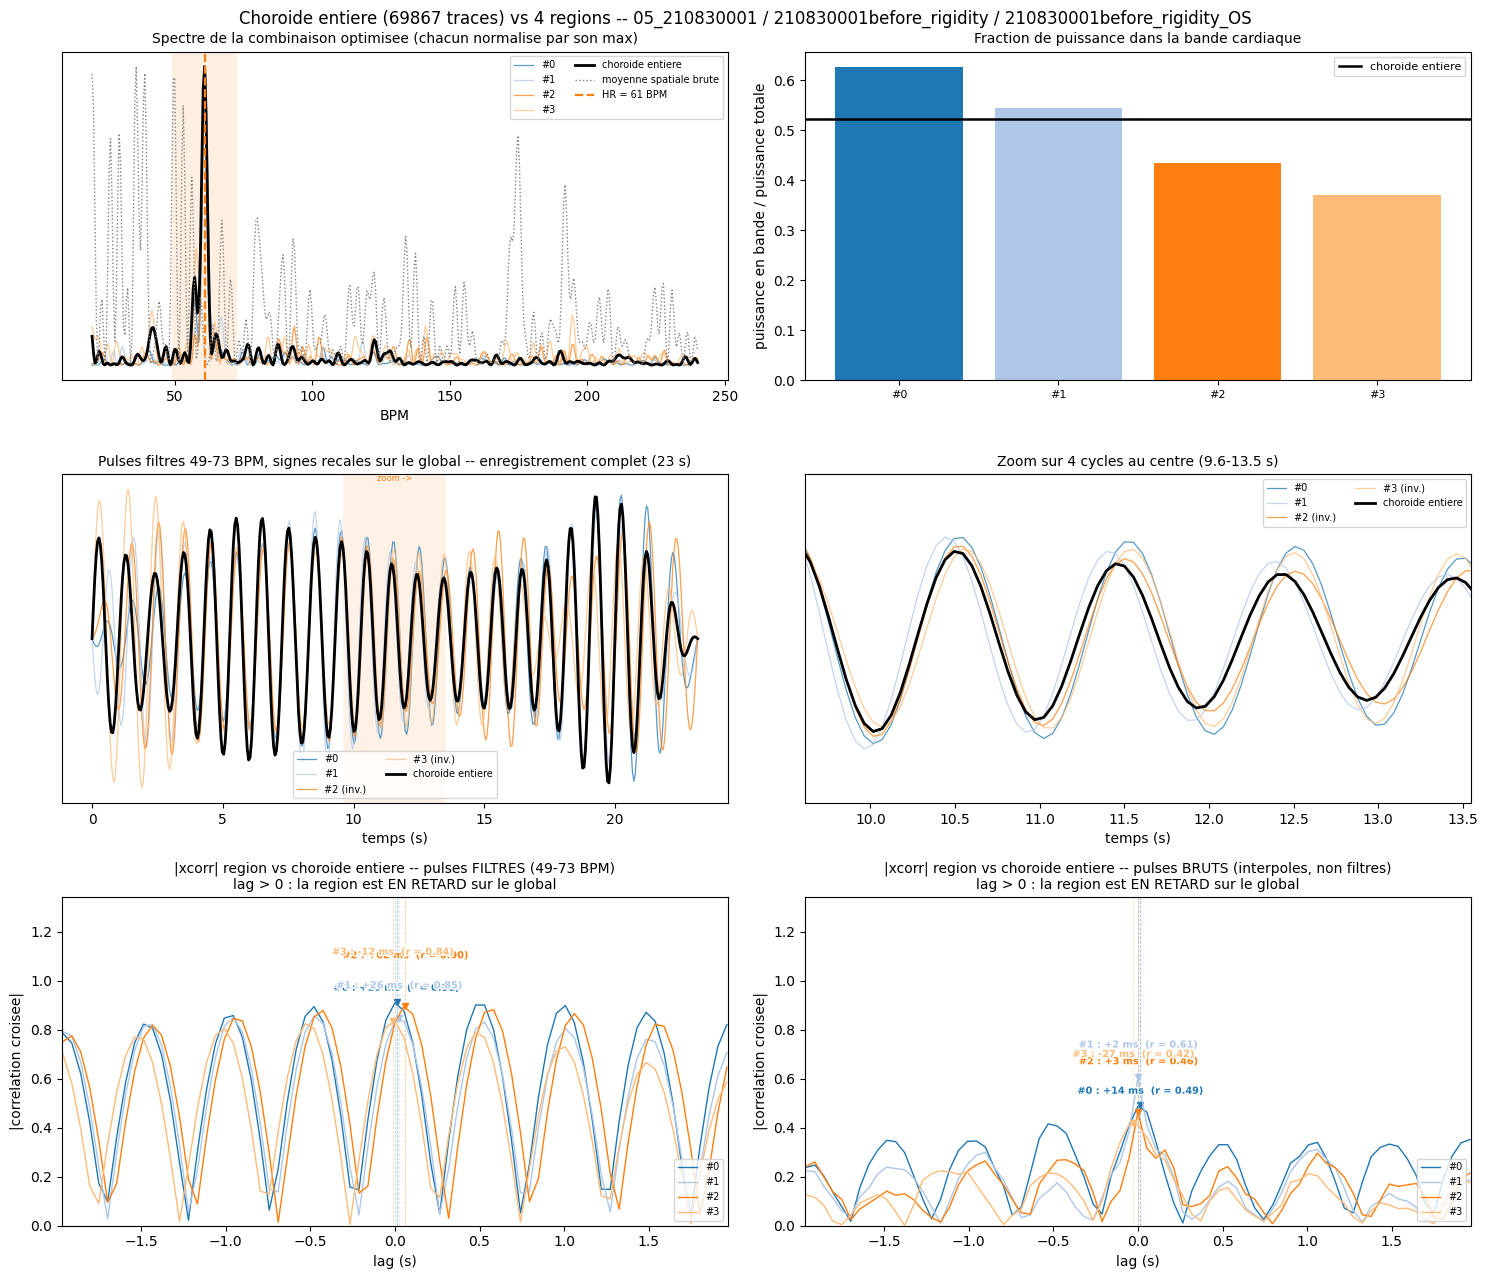

In [90]:
# --- Comparaison chiffree : global <-> regions -------------------------------
# Les correlations croisees sont calculees DEUX FOIS, sur les pulses filtres et
# sur les pulses bruts, avec exactement le meme traitement : z-score, |xc|, pic
# local le plus proche du lag 0. Memes conventions qu'a la section 12 -- un lag
# > 0 signifie que la region est EN RETARD sur le pulse global.
#
# Les pulses bruts vivent sur `t` (horodatages reels, non uniformes) : ils sont
# interpoles sur `u_time` comme dans `Y_raw`, sans quoi un decalage en
# echantillons ne se traduit pas en secondes.
def _z(y):
    return (y - np.nanmean(y)) / (np.nanstd(y) + 1e-12)


y_all_raw_u = np.interp(u_time, t, opt_all["y"])
Z_ALL = {"filtres": _z(opt_all["y_filt"]), "bruts": _z(y_all_raw_u)}
SIG_REG = {"filtres": Y_filt, "bruts": Y_raw}

XC_ALL = {}
for _name in ("filtres", "bruts"):
    z_ref = np.nan_to_num(Z_ALL[_name], nan=0.0)
    d = {"xc": {}, "lag": {}, "r": {}, "r0": {}}
    for r in VALID:
        zr = np.nan_to_num(_z(SIG_REG[_name][r]), nan=0.0)
        xc = np.correlate(zr / Tu, z_ref, mode="full")[win]
        d["xc"][r] = xc
        d["r0"][r] = float(xc[i_zero])
        d["lag"][r], d["r"][r] = nearest_peak(np.abs(xc))
    XC_ALL[_name] = d

# Alias : la version filtree reste la reference du reste du notebook.
xc_vs_all = XC_ALL["filtres"]["xc"]
lag_vs_all = XC_ALL["filtres"]["lag"]
r_vs_all = XC_ALL["filtres"]["r"]
r0_vs_all = XC_ALL["filtres"]["r0"]

hdr = (f"{'':7s}{'traces':>8s}{'pic (BPM)':>11s}{'en bande':>10s}{'objectif':>10s}"
       f" | {'r(lag0)':>8s}{'|r| pic':>9s}{'lag (ms)':>10s}"
       f" | {'r(lag0)':>8s}{'|r| pic':>9s}{'lag (ms)':>10s}")
print(f"{'':46s} | {'--- pulses FILTRES ---':^27s} | {'--- pulses BRUTS ---':^27s}")
print(hdr)
print("-" * len(hdr))
print(f"{'GLOBAL':7s}{X_all.shape[1]:>8d}{opt_all['peak_bpm']:>11.1f}"
      f"{opt_all['frac']:>10.2%}{opt_all['objective']:>+10.4f}"
      f" | {'--':>8s}{'--':>9s}{'--':>10s} | {'--':>8s}{'--':>9s}{'--':>10s}")
for r in range(N_REGIONS):
    o = opt_reg[r]
    n_r = int((region_of_trace == r).sum())
    if o is None:
        print(f"#{r:<6d}{n_r:>8d}{'ECHEC (aucune candidate)':>41s}")
        continue
    f_, b_ = XC_ALL["filtres"], XC_ALL["bruts"]
    print(f"#{r:<6d}{n_r:>8d}{o['peak_bpm']:>11.1f}{o['frac']:>10.2%}"
          f"{o['objective']:>+10.4f}"
          f" | {f_['r0'][r]:>+8.2f}{f_['r'][r]:>9.2f}{f_['lag'][r] * 1e3:>+10.0f}"
          f" | {b_['r0'][r]:>+8.2f}{b_['r'][r]:>9.2f}{b_['lag'][r] * 1e3:>+10.0f}")

_fr = np.array([opt_reg[r]["frac"] for r in VALID])
print(f"\nfraction en bande  : global {opt_all['frac']:.2%}  |  regions "
      f"{_fr.min():.2%} -> {_fr.max():.2%} (mediane {np.median(_fr):.2%}) "
      f"-> {'les regions font mieux' if np.median(_fr) > opt_all['frac'] else 'le global fait mieux'}")
for _name in ("filtres", "bruts"):
    d = XC_ALL[_name]
    _r0 = np.array([abs(d["r0"][r]) for r in VALID])
    _lg = np.array([abs(d["lag"][r]) for r in VALID]) * 1e3
    print(f"pulses {_name:<8s} : |r| au lag 0 vs global {_r0.min():.2f} -> "
          f"{_r0.max():.2f} (mediane {np.median(_r0):.2f})  |  |lag| "
          f"{_lg.min():.0f} -> {_lg.max():.0f} ms (mediane {np.median(_lg):.0f} ms)")
print(f"reperes : pas de temps {dt_u * 1e3:.1f} ms, demi-periode cardiaque "
      f"{30_000 / hr:.0f} ms (ambiguite residuelle de |xc|)")

# --- Figure : 6 vues de la comparaison ---------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(15, 13))

# (a) Spectres : chaque courbe normalisee par son max (les amplitudes des
# valeurs singulieres ne sont pas comparables d'une echelle spatiale a l'autre).
ax = axes[0][0]
for r in VALID:
    Pr = opt_reg[r]["P"]
    ax.plot(bpm_axis, Pr / (Pr.max() + 1e-12), lw=0.9, alpha=0.75,
            color=CMAP_REG(r % 20), label=f"#{r}")
ax.plot(bpm_axis, opt_all["P"] / (opt_all["P"].max() + 1e-12), lw=2.0, color="k",
        label="choroide entiere")
ax.plot(bpm_axis, P_glob_raw / (P_glob_raw.max() + 1e-12), lw=1.0, color="0.5",
        ls=":", label="moyenne spatiale brute")
mark_hr(ax)
ax.set_title("Spectre de la combinaison optimisee (chacun normalise par son max)",
             fontsize=10)
ax.set_xlabel("BPM")
ax.set_yticks([])
ax.legend(fontsize=7, ncol=2)

# (b) Fraction en bande : la metrique optimisee, region par region.
ax = axes[0][1]
xs = np.arange(len(VALID))
ax.bar(xs, [opt_reg[r]["frac"] for r in VALID],
       color=[CMAP_REG(r % 20) for r in VALID])
ax.axhline(opt_all["frac"], color="k", lw=1.8, label="choroide entiere")
ax.set_xticks(xs)
ax.set_xticklabels([f"#{r}" for r in VALID], fontsize=8)
ax.set_ylabel("puissance en bande / puissance totale")
ax.set_title("Fraction de puissance dans la bande cardiaque", fontsize=10)
ax.legend(fontsize=8)


# Signe d'AFFICHAGE : celui d'une combinaison SVD est arbitraire (il n'est fixe,
# region par region, que contre la moyenne de sa propre region), donc deux
# pulses "en opposition" ne le sont souvent que par convention. Pour le domaine
# temporel on retourne toute region dont la covariance avec le pulse global est
# negative -- c'est le signe de `r0`, la correlation au lag 0 deja calculee.
# Les correlations croisees, elles, restent inchangees : elles passent par |xc|
# et `r0` porte justement ce signe comme information.
sign_show = {r: (1.0 if XC_ALL["filtres"]["r0"][r] >= 0 else -1.0) for r in VALID}
_flip = [r for r in VALID if sign_show[r] < 0]
print(f"affichage temporel : {len(_flip)} region(s) inversee(s) pour l'affichage "
      f"(covariance < 0 avec le pulse global)"
      + (f" : {_flip}" if _flip else " : aucune"))


def plot_pulses(ax, xlim, title):
    """Pulses filtres reduits (divises par leur ecart-type) : le passe-bande
    retire une partie de la variance, seule la FORME est comparable. Les
    regions marquees `(inv.)` sont tracees changees de signe (voir `sign_show`)."""
    for r in VALID:
        y = sign_show[r] * Y_filt[r]
        ax.plot(u_time, y / (np.nanstd(y) + 1e-9), lw=0.9,
                alpha=0.75, color=CMAP_REG(r % 20),
                label=f"#{r}" + (" (inv.)" if sign_show[r] < 0 else ""))
    ax.plot(u_time, opt_all["y_filt"] / (np.nanstd(opt_all["y_filt"]) + 1e-9),
            lw=2.0, color="k", label="choroide entiere")
    if xlim is not None:
        ax.set_xlim(*xlim)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("temps (s)")
    ax.set_yticks([])
    ax.legend(fontsize=7, ncol=2)


# (c) Enregistrement COMPLET : montre si l'accord global/regions tient sur toute
# la duree ou seulement par endroits. Les ~7 s de bord portent le transitoire du
# FIR (noyau de 133 taps) -- elles sont grisees plutot que coupees.
_mid_c = 0.5 * (u_time[0] + u_time[-1])
_half_c = 2.0 * 60.0 / hr
ax = axes[1][0]
plot_pulses(ax, None, f"Pulses filtres {_LO_BPM:.0f}-{_HI_BPM:.0f} BPM, signes "
                      f"recales sur le global -- enregistrement complet "
                      f"({u_time[-1] - u_time[0]:.0f} s)")
ax.axvspan(_mid_c - _half_c, _mid_c + _half_c, color="C1", alpha=0.10, lw=0,
           zorder=0)                                   # la fenetre du zoom
ax.text(_mid_c, ax.get_ylim()[1], "zoom ->", fontsize=6, ha="center", va="top",
        color="C1")

# (d) Zoom au CENTRE : les bords portent le transitoire du FIR et donneraient un
# faux dephasage.
plot_pulses(axes[1][1], (_mid_c - _half_c, _mid_c + _half_c),
            f"Zoom sur 4 cycles au centre "
            f"({_mid_c - _half_c:.1f}-{_mid_c + _half_c:.1f} s)")


def plot_xc_vs_global(ax, name, title):
    """|correlation croisee| de chaque region contre le pulse global.

    Chaque pic retenu est annote de son lag ET de sa correlation, a la verticale
    du marqueur. Les etiquettes sont reparties sur `n_lvl` hauteurs en alternance
    (au plus 5, sinon la pile mange tout le panneau quand il y a 15 regions) :
    deux pics au meme lag ne se recouvrent donc pas, et la separation horizontale
    fait le reste.
    """
    d = XC_ALL[name]
    n_lvl = min(len(VALID), 5)
    for k, r in enumerate(VALID):
        col = CMAP_REG(r % 20)
        lag, val = d["lag"][r], d["r"][r]
        ax.plot(lags, np.abs(d["xc"][r]), lw=1.0, color=col, label=f"#{r}")
        ax.plot([lag], [val], "v", ms=5, color=col)
        ax.axvline(lag, color=col, lw=0.6, ls="--", alpha=0.45, zorder=0)
        ax.annotate(f"#{r} : {lag * 1e3:+.0f} ms  (r = {val:.2f})",
                    xy=(lag, val), xytext=(0, 7 + 13 * (k % n_lvl)),
                    textcoords="offset points", ha="center", va="bottom",
                    fontsize=7, color=col, fontweight="bold", annotation_clip=False,
                    path_effects=[pe.withStroke(linewidth=2.0, foreground="white")])
    ax.axvline(0.0, color="0.7", lw=0.6, ls=":")
    ax.set_xlim(-LAG_MAX, LAG_MAX)
    ax.set_ylim(0, 1.10 + 0.06 * n_lvl)            # place pour les annotations
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("lag (s)")
    ax.set_ylabel("|correlation croisee|")
    ax.legend(fontsize=7, loc="lower right")


# (e) et (f) : meme mesure, meme mise en page, sur les pulses filtres puis bruts.
# L'ecart entre les deux dit combien du dephasage vient du passe-bande.
plot_xc_vs_global(axes[2][0], "filtres",
                  f"|xcorr| region vs choroide entiere -- pulses FILTRES "
                  f"({_LO_BPM:.0f}-{_HI_BPM:.0f} BPM)\n"
                  f"lag > 0 : la region est EN RETARD sur le global")
plot_xc_vs_global(axes[2][1], "bruts",
                  "|xcorr| region vs choroide entiere -- pulses BRUTS "
                  "(interpoles, non filtres)\n"
                  "lag > 0 : la region est EN RETARD sur le global")

fig.suptitle(f"Choroide entiere ({X_all.shape[1]} traces) vs {len(VALID)} regions "
             f"-- {ASTRO} / {MOMENT} / {CONDITION}", fontsize=12)
fig.tight_layout()


correlation spatiale des deux cartes de poids : +0.01 sur 48313 pixels
poids global par region (moyenne +/- ecart-type) :
  #0   +0.035 +/- 0.130   (|w| median 0.084)
  #1   +0.031 +/- 0.122   (|w| median 0.081)
  #2   +0.016 +/- 0.096   (|w| median 0.065)
  #3   +0.006 +/- 0.095   (|w| median 0.063)


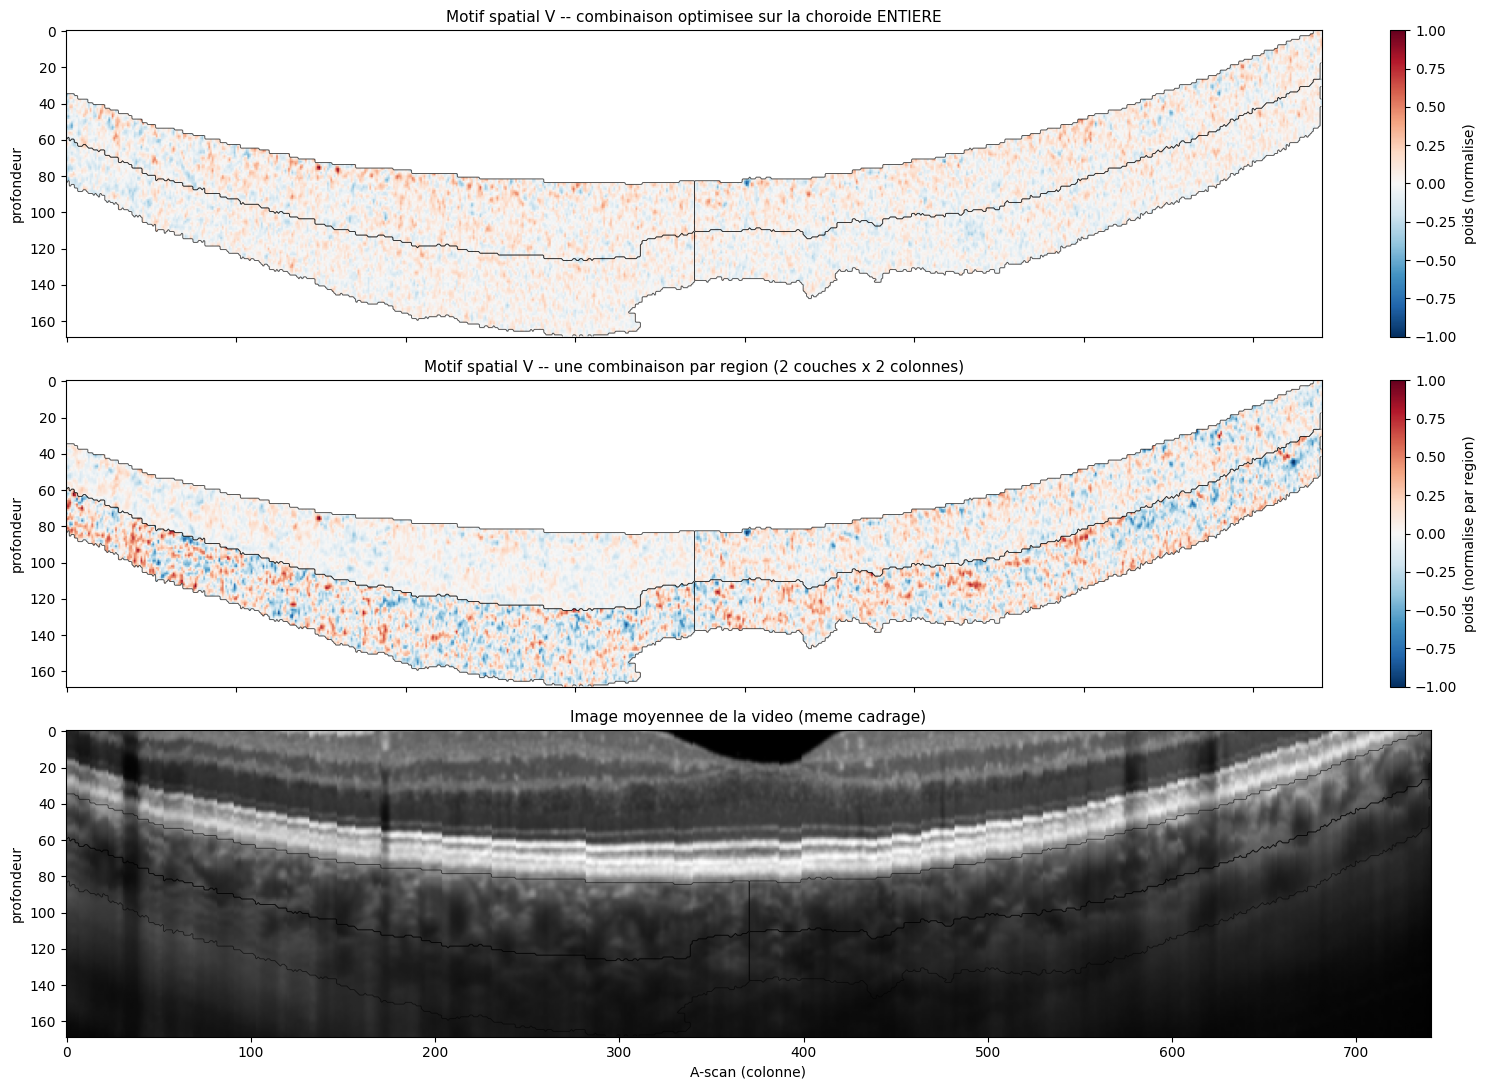

In [85]:
# --- Motif spatial : combinaison globale vs combinaisons regionales ----------
# La combinaison globale est normalisee par son propre max|.| ; `Vmap` (calcule
# a la section 11) l'est region par region. C'est la STRUCTURE qu'on compare :
# le decoupage impose-t-il des frontieres que le poids global ne montre pas ?
pat_all = np.asarray(opt_all["pattern"], dtype=float)[is1]
map_all = as_image(pat_all / (np.abs(pat_all).max() + 1e-12))

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True, sharey=True)
im = axes[0].imshow(map_all, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
fig.colorbar(im, ax=axes[0], fraction=0.03, label="poids (normalise)")
axes[0].set_title("Motif spatial V -- combinaison optimisee sur la choroide ENTIERE",
                  fontsize=11)

im = axes[1].imshow(Vmap[_BOX], cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
fig.colorbar(im, ax=axes[1], fraction=0.03, label="poids (normalise par region)")
axes[1].set_title(f"Motif spatial V -- une combinaison par region "
                  f"({N_LAYERS} couches x {N_COLS_REG} colonnes)", fontsize=11)

axes[2].imshow(mean_frame[_BOX], cmap="gray", aspect="auto")
axes[2].set_title("Image moyennee de la video (meme cadrage)", fontsize=11)
axes[2].set_xlabel("A-scan (colonne)")

reg_box = region_of_pixel[_BOX]
for ax in axes:
    ax.set_ylabel("profondeur")
    for r in range(N_REGIONS):
        m = reg_box == r
        if not m.any():
            continue
        ax.contour(m.astype(float), levels=[0.5], colors="k", linewidths=0.6,
                   alpha=0.6)

# Correlation spatiale des deux cartes, la ou les deux sont definies : mesure
# a quel point le decoupage change le poids donne a chaque pixel.
_a, _b = map_all.ravel(), Vmap[_BOX].ravel()
_ok = np.isfinite(_a) & np.isfinite(_b)
print(f"correlation spatiale des deux cartes de poids : "
      f"{np.corrcoef(_a[_ok], _b[_ok])[0, 1]:+.2f} sur {_ok.sum()} pixels")
print(f"poids global par region (moyenne +/- ecart-type) :")
for r in range(N_REGIONS):
    w = pat_all[region_of_trace[is1] == r]
    w = w / (np.abs(pat_all).max() + 1e-12)
    print(f"  #{r:<3d} {w.mean():+.3f} +/- {w.std():.3f}   "
          f"(|w| median {np.median(np.abs(w)):.3f})")
fig.tight_layout()
